In [ ]:
import json
import pandas as pd
import numpy as np

# CHANGE THIS IF NEEDED
SUMMARY_PATH = "/home/akapociu/ift/interactiondynamics/results/iftxbaseline_all_ds.jsonl"

rows = []
with open(SUMMARY_PATH, "r") as f:
    for line in f:
        rows.append(json.loads(line))

df = pd.DataFrame(rows)

print("Loaded rows:", len(df))
display(df.head(2))

Loaded rows: 32


,dataset,name,seed,epochs,best_val_mrr,best_epoch,best_snapshot,final_snapshot,wall_sec
0,Wikipedia,Wikipedia_agg=sum|update=ift_update|do=0.0|sdo...,0,10,0.720319,1,"{'epoch': 1, 'train_step': {'loss': 1.76800941...","{'epoch': 10, 'train_step': {'loss': 1.6968736...",64.322249
1,Wikipedia,Wikipedia_agg=sum|update=tgn_gru|do=0.0|sdo=0....,0,10,0.862729,8,"{'epoch': 8, 'train_step': {'loss': 0.64302937...","{'epoch': 10, 'train_step': {'loss': 0.6119984...",50.002738


In [ ]:
def parse_run_name(name: str) -> dict:
    """
    Example input:
    Wikipedia__agg=sum|update=tgn_gru|do=0.3|sdo=0.0|time=False|softplus|dt=0.05|gamma=0.0|k0=1.0|cap=none

    Returns:
    {
        "agg": "sum",
        "update": "tgn_gru",
        "do": "0.3",
        "sdo": "0.0",
        "time": "False",
        "ift_kappa_param": "softplus",
        "dt": "0.05",
        "gamma": "0.0",
        "k0": "1.0",
        "cap": "none",
    }
    """
    if pd.isna(name):
        return {}

    # remove dataset prefix if present
    if "__" in name:
        _, config_part = name.split("__", 1)
    else:
        config_part = name

    pieces = config_part.split("|")
    out = {}

    for piece in pieces:
        if "=" in piece:
            k, v = piece.split("=", 1)
            out[k] = v
        else:
            # this handles bare tokens like "softplus" / "exp"
            # assumes those correspond to IFT kappa parameterization
            if piece in {"softplus", "exp"}:
                out["ift_kappa_param"] = piece
            else:
                out.setdefault("extra_tokens", []).append(piece)

    return out

parsed = df["name"].apply(parse_run_name).apply(pd.Series)
df = pd.concat([df, parsed], axis=1)

print("Parsed columns added:")
print(sorted(parsed.columns.tolist()))
display(df.head(2))

Parsed columns added:
['LastFM_agg', 'MOOC_agg', 'Reddit_agg', 'Wikipedia_agg', 'cap', 'do', 'dt', 'gamma', 'ift_kappa_param', 'k0', 'sdo', 'time', 'update']


,dataset,name,seed,epochs,best_val_mrr,best_epoch,best_snapshot,final_snapshot,wall_sec,Wikipedia_agg,...,sdo,time,ift_kappa_param,dt,gamma,k0,cap,Reddit_agg,MOOC_agg,LastFM_agg
0,Wikipedia,Wikipedia_agg=sum|update=ift_update|do=0.0|sdo...,0,10,0.720319,1,"{'epoch': 1, 'train_step': {'loss': 1.76800941...","{'epoch': 10, 'train_step': {'loss': 1.6968736...",64.322249,sum,...,0.0,False,softplus,0.05,0.0,0.1,none,NaN,NaN,NaN
1,Wikipedia,Wikipedia_agg=sum|update=tgn_gru|do=0.0|sdo=0....,0,10,0.862729,8,"{'epoch': 8, 'train_step': {'loss': 0.64302937...","{'epoch': 10, 'train_step': {'loss': 0.6119984...",50.002738,sum,...,0.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# convert obvious numeric columns if present
numeric_cols = ["do", "sdo", "dt", "gamma", "k0", "best_val_mrr", "best_epoch", "wall_sec", "seed", "epochs"]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# booleans
if "time" in df.columns:
    df["time"] = df["time"].map({"True": True, "False": False}).fillna(df["time"])

# normalize some naming just in case
rename_map = {
    "agg": "aggregator",
}
for old, new in rename_map.items():
    if old in df.columns and new not in df.columns:
        df[new] = df[old]

# helper to safely pull nested metrics
def nested_get(obj, path, default=np.nan):
    cur = obj
    try:
        for p in path:
            cur = cur[p]
        return cur
    except Exception:
        return default

# commonly useful extracted metrics
if "best_snapshot" in df.columns:
    df["best_test_mrr"] = df["best_snapshot"].apply(lambda x: nested_get(x, ["test", "mrr"]))
    df["best_train_eval_mrr"] = df["best_snapshot"].apply(lambda x: nested_get(x, ["train_eval", "mrr"]))
    df["best_val_loss"] = df["best_snapshot"].apply(lambda x: nested_get(x, ["val", "loss"]))
    df["best_test_loss"] = df["best_snapshot"].apply(lambda x: nested_get(x, ["test", "loss"]))
    df["best_epoch_train_step_mrr"] = df["best_snapshot"].apply(lambda x: nested_get(x, ["train_step", "mrr"]))
    df["best_epoch_kappa_mean"] = df["best_snapshot"].apply(lambda x: nested_get(x, ["train_step", "kappa_mean"]))

if "final_snapshot" in df.columns:
    df["final_test_mrr"] = df["final_snapshot"].apply(lambda x: nested_get(x, ["test", "mrr"]))
    df["final_val_mrr"] = df["final_snapshot"].apply(lambda x: nested_get(x, ["val", "mrr"]))

# useful generalization gap
if "best_val_mrr" in df.columns and "best_test_mrr" in df.columns:
    df["val_test_gap"] = df["best_val_mrr"] - df["best_test_mrr"]

print("Columns now available:")
print(df.columns.tolist())
display(df.head(2))

Columns now available:
['dataset', 'name', 'seed', 'epochs', 'best_val_mrr', 'best_epoch', 'best_snapshot', 'final_snapshot', 'wall_sec', 'Wikipedia_agg', 'update', 'do', 'sdo', 'time', 'ift_kappa_param', 'dt', 'gamma', 'k0', 'cap', 'Reddit_agg', 'MOOC_agg', 'LastFM_agg', 'best_test_mrr', 'best_train_eval_mrr', 'best_val_loss', 'best_test_loss', 'best_epoch_train_step_mrr', 'best_epoch_kappa_mean', 'final_test_mrr', 'final_val_mrr', 'val_test_gap']


/tmp/ipykernel_2424847/3546402483.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["time"] = df["time"].map({"True": True, "False": False}).fillna(df["time"])


,dataset,name,seed,epochs,best_val_mrr,best_epoch,best_snapshot,final_snapshot,wall_sec,Wikipedia_agg,...,LastFM_agg,best_test_mrr,best_train_eval_mrr,best_val_loss,best_test_loss,best_epoch_train_step_mrr,best_epoch_kappa_mean,final_test_mrr,final_val_mrr,val_test_gap
0,Wikipedia,Wikipedia_agg=sum|update=ift_update|do=0.0|sdo...,0,10,0.720319,1,"{'epoch': 1, 'train_step': {'loss': 1.76800941...","{'epoch': 10, 'train_step': {'loss': 1.6968736...",64.322249,sum,...,NaN,0.737898,0.638518,2.656256,2.673706,0.680612,0.127743,0.735437,0.712061,-0.017579
1,Wikipedia,Wikipedia_agg=sum|update=tgn_gru|do=0.0|sdo=0....,0,10,0.862729,8,"{'epoch': 8, 'train_step': {'loss': 0.64302937...","{'epoch': 10, 'train_step': {'loss': 0.6119984...",50.002738,sum,...,NaN,0.859780,0.883496,0.821577,0.859743,0.881504,NaN,0.742143,0.765180,0.002949


In [ ]:
def filter_runs(df, filters=None, verbose=True):
    """
    Flexible filtering helper.

    Rules:
    - value=None -> ignore this field
    - scalar -> exact match
    - list/tuple/set -> isin(...)
    - callable -> keep rows where callable(series) is True
    """
    out = df.copy()

    if filters is None:
        if verbose:
            print("No filters applied.")
        return out

    for col, value in filters.items():
        if value is None:
            continue

        if col not in out.columns:
            print(f"[filter_runs] Warning: column '{col}' not found. Skipping.")
            continue

        before = len(out)

        if callable(value):
            mask = value(out[col])
            out = out[mask]
        elif isinstance(value, (list, tuple, set)):
            out = out[out[col].isin(value)]
        else:
            out = out[out[col] == value]

        after = len(out)

        if verbose:
            print(f"Filter {col}={value} -> {before} -> {after}")

    return out

In [ ]:
FOCUS_FILTERS = {
    "dataset": None,            # e.g. ["Wikipedia", "Reddit"]
    "aggregator": None,         # e.g. ["sum", "ift", "deepsets"]
    "update": None,             # e.g. ["tgn_gru", "ift_update"]
    "do": [0.0, 0.3],                  # dropout
    "sdo": None,                # scorer dropout
    "time": None,               # True / False
    "ift_kappa_param": None,    # "softplus" / "exp"
    "dt": None,
    "gamma": None,
    "k0": None,
    "cap": None,
    "seed": None,
}

focus_df = filter_runs(df, FOCUS_FILTERS, verbose=True)

active_filters = {k: v for k, v in FOCUS_FILTERS.items() if v is not None}
print("\nActive filters:", active_filters if active_filters else "None")
print("Selected rows:", len(focus_df))

display(focus_df.head(5))

Filter do=[0.0, 0.3] -> 32 -> 32

Active filters: {'do': [0.0, 0.3]}
Selected rows: 32


,dataset,name,seed,epochs,best_val_mrr,best_epoch,best_snapshot,final_snapshot,wall_sec,Wikipedia_agg,...,LastFM_agg,best_test_mrr,best_train_eval_mrr,best_val_loss,best_test_loss,best_epoch_train_step_mrr,best_epoch_kappa_mean,final_test_mrr,final_val_mrr,val_test_gap
0,Wikipedia,Wikipedia_agg=sum|update=ift_update|do=0.0|sdo...,0,10,0.720319,1,"{'epoch': 1, 'train_step': {'loss': 1.76800941...","{'epoch': 10, 'train_step': {'loss': 1.6968736...",64.322249,sum,...,NaN,0.737898,0.638518,2.656256,2.673706,0.680612,0.127743,0.735437,0.712061,-0.017579
1,Wikipedia,Wikipedia_agg=sum|update=tgn_gru|do=0.0|sdo=0....,0,10,0.862729,8,"{'epoch': 8, 'train_step': {'loss': 0.64302937...","{'epoch': 10, 'train_step': {'loss': 0.6119984...",50.002738,sum,...,NaN,0.859780,0.883496,0.821577,0.859743,0.881504,NaN,0.742143,0.765180,0.002949
2,Wikipedia,Wikipedia_agg=sum|update=ift_update|do=0.3|sdo...,0,10,0.718662,1,"{'epoch': 1, 'train_step': {'loss': 1.77304897...","{'epoch': 10, 'train_step': {'loss': 1.6823147...",63.447291,sum,...,NaN,0.739066,0.644056,2.756737,2.775384,0.678615,0.127743,0.738087,0.716195,-0.020404
3,Wikipedia,Wikipedia_agg=sum|update=tgn_gru|do=0.3|sdo=0....,0,10,0.844572,6,"{'epoch': 6, 'train_step': {'loss': 0.66762513...","{'epoch': 10, 'train_step': {'loss': 0.6286732...",50.112820,sum,...,NaN,0.842635,0.857422,0.906570,0.954810,0.874647,NaN,0.826502,0.834759,0.001937
4,Wikipedia,Wikipedia_agg=ift|update=ift_update|do=0.0|sdo...,0,10,0.814892,1,"{'epoch': 1, 'train_step': {'loss': 1.43268040...","{'epoch': 10, 'train_step': {'loss': 1.1841205...",79.589245,ift,...,NaN,0.834277,0.754056,2.197283,2.185519,0.781759,0.082568,0.829194,0.804426,-0.019384


In [76]:
def quick_value_counts(focus_df, cols):
    for col in cols:
        if col in focus_df.columns:
            print(f"\n=== {col} ===")
            display(focus_df[col].value_counts(dropna=False).to_frame("count"))

quick_value_counts(
    focus_df,
    ["dataset", "aggregator", "update", "do", "sdo", "time", "ift_kappa_param", "dt", "gamma", "k0", "cap", "seed"]
)


=== dataset ===


,count
dataset,
Wikipedia,4
Reddit,4
MOOC,4
LastFM,4



=== update ===


,count
update,
ift_update,8
tgn_gru,8



=== do ===


...

,count
k0,
0.1,8
NaN,8



=== cap ===


,count
cap,
none,8
NaN,8



=== seed ===


,count
seed,
0,16


In [ ]:
group_cols = [c for c in ["dataset", "aggregator", "update", "do", "sdo", "time"] if c in focus_df.columns]

summary_table = (
    focus_df.groupby(group_cols, dropna=False)
    .agg(
        avg_val_mrr=("best_val_mrr", "mean"),
        std_val_mrr=("best_val_mrr", "std"),
        avg_test_mrr=("best_test_mrr", "mean"),
        std_test_mrr=("best_test_mrr", "std"),
        avg_gap=("val_test_gap", "mean"),
        avg_wall_sec=("wall_sec", "mean"),
        n_runs=("name", "count"),
    )
    .reset_index()
    .sort_values(["dataset", "avg_val_mrr"], ascending=[True, False])
)

display(summary_table)

In [ ]:
from typing import Dict, Any

def parse_run_string(run_name: str) -> Dict[str, Any]:
    out = {
        "aggregator": None,
        "update": None,
        "dropout": None,
        "scorer_dropout": None,
        "time_features": None,
        "ift_kappa_param": None,
        "ift_dt": None,
        "ift_gamma": None,
        "ift_kappa_init": None,
        "ift_kappa_cap": None,
        "ift_kappa_max": None,
    }

    if run_name is None:
        return out

    # Handle either:
    #   Wikipedia__agg=...
    # or
    #   Reddit_agg=...
    if "__" in run_name:
        _, run_body = run_name.split("__", 1)
    elif "_agg=" in run_name:
        run_body = run_name.split("_agg=", 1)[1]
        run_body = "agg=" + run_body
    else:
        run_body = run_name

    parts = run_body.split("|")
    for part in parts:
        if "=" in part:
            k, v = part.split("=", 1)

            if k == "agg":
                out["aggregator"] = v
            elif k == "update":
                out["update"] = v
            elif k == "do":
                out["dropout"] = float(v)
            elif k == "sdo":
                out["scorer_dropout"] = float(v)
            elif k == "time":
                out["time_features"] = (v == "True")
            elif k == "dt":
                out["ift_dt"] = float(v)
            elif k == "gamma":
                out["ift_gamma"] = float(v)
            elif k == "k0":
                out["ift_kappa_init"] = float(v)
            elif k == "cap":
                if v == "none":
                    out["ift_kappa_cap"] = False
                    out["ift_kappa_max"] = None
                else:
                    out["ift_kappa_cap"] = True
                    try:
                        out["ift_kappa_max"] = float(v)
                    except ValueError:
                        out["ift_kappa_max"] = v
        else:
            if part in {"softplus", "exp"}:
                out["ift_kappa_param"] = part

    return out

In [ ]:
def load_summary_jsonl(path: Path) -> pd.DataFrame:
    rows = []

    with path.open("r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            row = json.loads(line)

            dataset = row.get("dataset", None)
            run_name = row.get("name", row.get("run", None))
            seed = row.get("seed", None)
            best_val_mrr = row.get("best_val_mrr", None)
            best_epoch = row.get("best_epoch", None)
            test_mrr = extract_test_mrr(row)
            wall_sec = extract_walltime(row)

            parsed = parse_run_string(run_name)

            clean = {
                "dataset": dataset,
                "run_name": run_name,
                "seed": seed,
                "best_val_mrr": best_val_mrr,
                "best_test_mrr": test_mrr,
                "wall_sec": wall_sec,
                "best_epoch": best_epoch,

                # best snapshot metrics
                "best_val_early_mrr": safe_get(row, "best_snapshot", "val", "early_mrr", default=None),
                "best_val_late_mrr": safe_get(row, "best_snapshot", "val", "late_mrr", default=None),
                "best_test_early_mrr": safe_get(row, "best_snapshot", "test", "early_mrr", default=None),
                "best_test_late_mrr": safe_get(row, "best_snapshot", "test", "late_mrr", default=None),

                # final snapshot metrics
                "final_val_mrr": safe_get(row, "final_snapshot", "val", "mrr", default=None),
                "final_test_mrr": safe_get(row, "final_snapshot", "test", "mrr", default=None),
                "final_val_early_mrr": safe_get(row, "final_snapshot", "val", "early_mrr", default=None),
                "final_val_late_mrr": safe_get(row, "final_snapshot", "val", "late_mrr", default=None),
                "final_test_early_mrr": safe_get(row, "final_snapshot", "test", "early_mrr", default=None),
                "final_test_late_mrr": safe_get(row, "final_snapshot", "test", "late_mrr", default=None),

                **parsed,
            }
            rows.append(clean)

    return pd.DataFrame(rows)


summary_df = load_summary_jsonl(SUMMARY_PATH)
summary_df["overfit_gap"] = summary_df["best_test_mrr"] - summary_df["final_test_mrr"]
summary_df["peaked_early"] = summary_df["best_epoch"] <= 2
summary_df["completed_run"] = summary_df["final_test_mrr"].notna()
summary_df.shape

(32, 31)

In [ ]:
wiki_df   = summary_df[summary_df["dataset"] == "Wikipedia"].copy()
reddit_df = summary_df[summary_df["dataset"] == "Reddit"].copy()
mooc_df   = summary_df[summary_df["dataset"] == "MOOC"].copy()
lastfm_df = summary_df[summary_df["dataset"] == "LastFM"].copy()

dataset_dfs = {
    "Wikipedia": wiki_df,
    "Reddit": reddit_df,
    "MOOC": mooc_df,
    "LastFM": lastfm_df,
}

for name, focus_df in dataset_dfs.items():
    print(name, focus_df.shape)

Wikipedia (8, 31)
Reddit (8, 31)
MOOC (8, 31)
LastFM (8, 31)


In [ ]:
def build_dataset_model_ranking(focus_df: pd.DataFrame, expected_seeds: int = 3) -> pd.DataFrame:
    out = (
        focus_df.groupby(["dataset", "aggregator", "update"], dropna=False)
          .agg(
              n_seeds=("seed", "nunique"),
              avg_val_mrr=("best_val_mrr", "mean"),
              std_val_mrr=("best_val_mrr", "std"),
              mean_test_mrr=("best_test_mrr", "mean"),
              std_test_mrr=("best_test_mrr", "std"),
              mean_overfit_gap=("overfit_gap", "mean"),
              peaked_early_rate=("peaked_early", "mean"),
              avg_early_val_mrr=("best_val_early_mrr", "mean"),
              avg_late_val_mrr=("best_val_late_mrr", "mean"),
              avg_early_test_mrr=("best_test_early_mrr", "mean"),
              avg_late_test_mrr=("best_test_late_mrr", "mean"),
              wall_sec_mean=("wall_sec", "mean"),
              wall_sec_std=("wall_sec", "std"),
          )
          .reset_index()
    )

    out["did_complete"] = out["n_seeds"] == expected_seeds

    out = out.sort_values(
        by=["avg_val_mrr", "mean_test_mrr"],
        ascending=[False, False]
    ).reset_index(drop=True)

    out["rank_in_dataset"] = np.arange(1, len(out) + 1)

    return out[
        [
            "dataset",
            "aggregator",
            "update",
            "rank_in_dataset",
            "avg_val_mrr",
            "std_val_mrr",
            "mean_test_mrr",
            "std_test_mrr",
            "mean_overfit_gap",
            "peaked_early_rate",
            "avg_early_val_mrr",
            "avg_late_val_mrr",
            "avg_early_test_mrr",
            "avg_late_test_mrr",
            "wall_sec_mean",
            "wall_sec_std",
            "n_seeds",
            "did_complete",
        ]
    ]

In [ ]:
rank_all_by_dataset = {
    ds: build_dataset_model_ranking(focus_df, expected_seeds=EXPECTED_SEEDS)
    for ds, focus_df in dataset_dfs.items()
}

wiki_rank_all   = rank_all_by_dataset["Wikipedia"]
reddit_rank_all = rank_all_by_dataset["Reddit"]
mooc_rank_all   = rank_all_by_dataset["MOOC"]
lastfm_rank_all = rank_all_by_dataset["LastFM"]

display(wiki_rank_all)
display(reddit_rank_all)
display(mooc_rank_all)
display(lastfm_rank_all)

,dataset,aggregator,update,rank_in_dataset,avg_val_mrr,std_val_mrr,mean_test_mrr,std_test_mrr,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean,wall_sec_std,n_seeds,did_complete
0,Wikipedia,ift,tgn_gru,1,0.860470,0.000526,0.866619,0.001402,0.001956,0.5,0.894017,0.857115,0.915098,0.861866,64.343744,0.093543,1,False
1,Wikipedia,sum,tgn_gru,2,0.853650,0.012839,0.851207,0.012123,0.066885,0.0,0.849432,0.854072,0.861825,0.850166,50.057779,0.077840,1,False
2,Wikipedia,ift,ift_update,3,0.815370,0.000676,0.832759,0.002147,0.004137,1.0,0.881135,0.808793,0.904380,0.825737,79.671012,0.115637,1,False
3,Wikipedia,sum,ift_update,4,0.719491,0.001172,0.738482,0.000825,0.001720,1.0,0.798951,0.711545,0.820201,0.730470,63.884770,0.618689,1,False


,dataset,aggregator,update,rank_in_dataset,avg_val_mrr,std_val_mrr,mean_test_mrr,std_test_mrr,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean,wall_sec_std,n_seeds,did_complete
0,Reddit,ift,tgn_gru,1,0.944302,0.000026,0.944389,0.000199,0.000287,0.0,0.932352,0.945497,0.936589,0.945153,139.557679,0.148721,1,False
1,Reddit,sum,tgn_gru,2,0.924061,0.007080,0.924529,0.006371,0.213316,0.0,0.872522,0.929215,0.878324,0.929059,125.129656,0.124929,1,False
2,Reddit,sum,ift_update,3,0.894517,0.002380,0.892539,0.000897,0.008854,0.0,0.858584,0.898110,0.856076,0.896114,139.363141,0.068709,1,False
3,Reddit,ift,ift_update,4,0.882666,0.012829,0.892630,0.010351,0.060788,0.0,0.872895,0.883643,0.887728,0.893111,156.062088,0.106712,1,False


,dataset,aggregator,update,rank_in_dataset,avg_val_mrr,std_val_mrr,mean_test_mrr,std_test_mrr,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean,wall_sec_std,n_seeds,did_complete
0,MOOC,ift,tgn_gru,1,0.973475,0.012101,0.966641,0.018681,-0.001068,0.5,0.980039,0.972791,0.951928,0.968157,90.082396,0.288234,1,False
1,MOOC,sum,tgn_gru,2,0.965088,0.003597,0.959396,0.003039,0.007824,0.0,0.959980,0.965620,0.939933,0.961402,76.926949,0.040329,1,False
2,MOOC,sum,ift_update,3,0.960398,0.000419,0.954615,0.002527,0.018246,1.0,0.967936,0.959612,0.954769,0.954599,87.740743,0.211142,1,False
3,MOOC,ift,ift_update,4,0.954223,0.002849,0.944223,0.007925,0.006611,0.5,0.965806,0.953016,0.925800,0.946122,102.454315,0.461150,1,False


,dataset,aggregator,update,rank_in_dataset,avg_val_mrr,std_val_mrr,mean_test_mrr,std_test_mrr,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean,wall_sec_std,n_seeds,did_complete
0,LastFM,sum,ift_update,1,0.634336,0.517055,0.652776,0.490943,0.000782,0.5,0.732045,0.634164,0.764300,0.652577,9059.483543,3.405305,1,False
1,LastFM,sum,tgn_gru,2,0.444146,0.013121,0.468793,0.007222,0.018020,0.0,0.563785,0.443936,0.577401,0.468600,8424.863604,15.011869,1,False
2,LastFM,ift,tgn_gru,3,0.434131,0.005681,0.465130,0.005610,0.006993,0.5,0.580270,0.433874,0.638325,0.464822,9073.429586,12.968917,1,False
3,LastFM,ift,ift_update,4,0.426110,0.000318,0.463654,0.000664,0.001809,0.0,0.568017,0.425861,0.630345,0.463358,9746.916855,6.435242,1,False


In [ ]:
def build_filtered_ranking(
    focus_df: pd.DataFrame,
    expected_seeds: int = 3,
    only_ift_aggregator: bool = False,
    only_ift_update: bool = False,
    only_ift_both: bool = False,
) -> pd.DataFrame:

    sub = focus_df.copy()

    if only_ift_both:
        sub = sub[(sub["aggregator"] == "ift") & (sub["update"] == "ift_update")]
    elif only_ift_aggregator:
        sub = sub[sub["aggregator"] == "ift"]
    elif only_ift_update:
        sub = sub[sub["update"] == "ift_update"]

    out = (
        sub.groupby(["dataset", "aggregator", "update"], dropna=False)
           .agg(
                n_seeds=("seed", "nunique"),
                avg_val_mrr=("best_val_mrr", "mean"),
                std_val_mrr=("best_val_mrr", "std"),
                mean_test_mrr=("best_test_mrr", "mean"),
                std_test_mrr=("best_test_mrr", "std"),
                mean_overfit_gap=("overfit_gap", "mean"),
                peaked_early_rate=("peaked_early", "mean"),

                avg_early_val_mrr=("best_val_early_mrr", "mean"),
                avg_late_val_mrr=("best_val_late_mrr", "mean"),
                avg_early_test_mrr=("best_test_early_mrr", "mean"),
                avg_late_test_mrr=("best_test_late_mrr", "mean"),

                walltime_mean_sec=("wall_sec", "mean"),
                walltime_std_sec=("wall_sec", "std"),
            )
           .reset_index()
    )

    out["did_complete"] = out["n_seeds"] == expected_seeds

    out = out.sort_values(
        by=["avg_val_mrr", "mean_test_mrr"],
        ascending=[False, False]
    ).reset_index(drop=True)

    out["rank_in_dataset"] = np.arange(1, len(out) + 1)

    return out[
        [
            "dataset",
            "aggregator",
            "update",
            "rank_in_dataset",
            "avg_val_mrr",
            "std_val_mrr",
            "mean_test_mrr",
            "std_test_mrr",
            "mean_overfit_gap",
            "peaked_early_rate",
            "avg_early_val_mrr",
            "avg_late_val_mrr",
            "avg_early_test_mrr",
            "avg_late_test_mrr",
            "wall_sec_mean",
            "wall_sec_std",
            "n_seeds",
            "did_complete",
        ]
    ]

In [ ]:
ift_tables_by_dataset = {}

for ds, full_table in rank_all_by_dataset.items():
    ift_tables_by_dataset[ds] = {
        "ift_aggregator_only": full_table[
            (full_table["aggregator"] == "ift") &
            (full_table["update"] != "ift_update")
        ].copy(),

        "ift_update_only": full_table[
            (full_table["update"] == "ift_update") &
            (full_table["aggregator"] != "ift")
        ].copy(),

        "ift_both": full_table[
            (full_table["aggregator"] == "ift") &
            (full_table["update"] == "ift_update")
        ].copy(),
    }

for ds in ["Wikipedia", "Reddit", "MOOC", "LastFM"]:
    print(f"\n===== {ds}: IFT aggregator only =====")
    display(ift_tables_by_dataset[ds]["ift_aggregator_only"])

    print(f"\n===== {ds}: IFT update only =====")
    display(ift_tables_by_dataset[ds]["ift_update_only"])

    print(f"\n===== {ds}: IFT aggregator + IFT update =====")
    display(ift_tables_by_dataset[ds]["ift_both"])


===== Wikipedia: IFT aggregator only =====


,dataset,aggregator,update,rank_in_dataset,avg_val_mrr,std_val_mrr,mean_test_mrr,std_test_mrr,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean,wall_sec_std,n_seeds,did_complete
0,Wikipedia,ift,tgn_gru,1,0.86047,0.000526,0.866619,0.001402,0.001956,0.5,0.894017,0.857115,0.915098,0.861866,64.343744,0.093543,1,False



===== Wikipedia: IFT update only =====


,dataset,aggregator,update,rank_in_dataset,avg_val_mrr,std_val_mrr,mean_test_mrr,std_test_mrr,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean,wall_sec_std,n_seeds,did_complete
3,Wikipedia,sum,ift_update,4,0.719491,0.001172,0.738482,0.000825,0.00172,1.0,0.798951,0.711545,0.820201,0.73047,63.88477,0.618689,1,False



===== Wikipedia: IFT aggregator + IFT update =====


...

,dataset,aggregator,update,rank_in_dataset,avg_val_mrr,std_val_mrr,mean_test_mrr,std_test_mrr,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean,wall_sec_std,n_seeds,did_complete
2,LastFM,ift,tgn_gru,3,0.434131,0.005681,0.46513,0.00561,0.006993,0.5,0.58027,0.433874,0.638325,0.464822,9073.429586,12.968917,1,False



===== LastFM: IFT update only =====


,dataset,aggregator,update,rank_in_dataset,avg_val_mrr,std_val_mrr,mean_test_mrr,std_test_mrr,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean,wall_sec_std,n_seeds,did_complete
0,LastFM,sum,ift_update,1,0.634336,0.517055,0.652776,0.490943,0.000782,0.5,0.732045,0.634164,0.7643,0.652577,9059.483543,3.405305,1,False



===== LastFM: IFT aggregator + IFT update =====


,dataset,aggregator,update,rank_in_dataset,avg_val_mrr,std_val_mrr,mean_test_mrr,std_test_mrr,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean,wall_sec_std,n_seeds,did_complete
3,LastFM,ift,ift_update,4,0.42611,0.000318,0.463654,0.000664,0.001809,0.0,0.568017,0.425861,0.630345,0.463358,9746.916855,6.435242,1,False


In [ ]:
big_rank_table = (
    summary_df.groupby(["dataset", "aggregator", "update"], dropna=False)
              .agg(
                    n_seeds=("seed", "nunique"),
                    avg_val_mrr=("best_val_mrr", "mean"),
                    std_val_mrr=("best_val_mrr", "std"),
                    mean_test_mrr=("best_test_mrr", "mean"),
                    std_test_mrr=("best_test_mrr", "std"),
                    mean_overfit_gap=("overfit_gap", "mean"),
                    peaked_early_rate=("peaked_early", "mean"),
                    avg_early_val_mrr=("best_val_early_mrr", "mean"),
                    avg_late_val_mrr=("best_val_late_mrr", "mean"),
                    avg_early_test_mrr=("best_test_early_mrr", "mean"),
                    avg_late_test_mrr=("best_test_late_mrr", "mean"),
                    wall_sec_mean=("wall_sec", "mean"),
                    wall_sec_std=("wall_sec", "std"),
              )
              .reset_index()
)

big_rank_table["did_complete"] = big_rank_table["n_seeds"] == EXPECTED_SEEDS

big_rank_table = big_rank_table.sort_values(
    by=["avg_val_mrr", "mean_test_mrr"],
    ascending=[False, False]
).reset_index(drop=True)

big_rank_table["global_rank"] = np.arange(1, len(big_rank_table) + 1)

big_rank_table = big_rank_table[
    [
        "dataset",
        "aggregator",
        "update",
        # "rank_in_dataset",
        "avg_val_mrr",
        "std_val_mrr",
        "mean_test_mrr",
        "std_test_mrr",
        "mean_overfit_gap",
        "peaked_early_rate",
        "avg_early_val_mrr",
        "avg_late_val_mrr",
        "avg_early_test_mrr",
        "avg_late_test_mrr",
        "wall_sec_mean",
        "wall_sec_std",
        "n_seeds",
        "did_complete",
    ]
]

display(big_rank_table.head(10))

,dataset,aggregator,update,avg_val_mrr,std_val_mrr,mean_test_mrr,std_test_mrr,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean,wall_sec_std,n_seeds,did_complete
0,MOOC,ift,tgn_gru,0.973475,0.012101,0.966641,0.018681,-0.001068,0.5,0.980039,0.972791,0.951928,0.968157,90.082396,0.288234,1,False
1,MOOC,sum,tgn_gru,0.965088,0.003597,0.959396,0.003039,0.007824,0.0,0.959980,0.965620,0.939933,0.961402,76.926949,0.040329,1,False
2,MOOC,sum,ift_update,0.960398,0.000419,0.954615,0.002527,0.018246,1.0,0.967936,0.959612,0.954769,0.954599,87.740743,0.211142,1,False
3,MOOC,ift,ift_update,0.954223,0.002849,0.944223,0.007925,0.006611,0.5,0.965806,0.953016,0.925800,0.946122,102.454315,0.461150,1,False
4,Reddit,ift,tgn_gru,0.944302,0.000026,0.944389,0.000199,0.000287,0.0,0.932352,0.945497,0.936589,0.945153,139.557679,0.148721,1,False
5,Reddit,sum,tgn_gru,0.924061,0.007080,0.924529,0.006371,0.213316,0.0,0.872522,0.929215,0.878324,0.929059,125.129656,0.124929,1,False
6,Reddit,sum,ift_update,0.894517,0.002380,0.892539,0.000897,0.008854,0.0,0.858584,0.898110,0.856076,0.896114,139.363141,0.068709,1,False
7,Reddit,ift,ift_update,0.882666,0.012829,0.892630,0.010351,0.060788,0.0,0.872895,0.883643,0.887728,0.893111,156.062088,0.106712,1,False
8,Wikipedia,ift,tgn_gru,0.860470,0.000526,0.866619,0.001402,0.001956,0.5,0.894017,0.857115,0.915098,0.861866,64.343744,0.093543,1,False
9,Wikipedia,sum,tgn_gru,0.853650,0.012839,0.851207,0.012123,0.066885,0.0,0.849432,0.854072,0.861825,0.850166,50.057779,0.077840,1,False


In [ ]:
combo_table = (
    summary_df.groupby(["dataset", "aggregator", "update"], dropna=False)
          .agg(
              n_seeds=("seed", "nunique"),
              mean_best_val_mrr=("best_val_mrr", "mean"),
              mean_best_test_mrr=("best_test_mrr", "mean"),
              completion_rate=("completed_run", "mean"),
              mean_overfit_gap=("overfit_gap", "mean"),
              peaked_early_rate=("peaked_early", "mean"),
              avg_early_val_mrr=("best_val_early_mrr", "mean"),
              avg_late_val_mrr=("best_val_late_mrr", "mean"),
              avg_early_test_mrr=("best_test_early_mrr", "mean"),
              avg_late_test_mrr=("best_test_late_mrr", "mean"),
              wall_sec_mean=("wall_sec", "mean"),
          )
          .reset_index()
)

display(combo_table)

,dataset,aggregator,update,n_seeds,mean_best_val_mrr,mean_best_test_mrr,completion_rate,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean
0,LastFM,ift,ift_update,1,0.426110,0.463654,1.0,0.001809,0.0,0.568017,0.425861,0.630345,0.463358,9746.916855
1,LastFM,ift,tgn_gru,1,0.434131,0.465130,1.0,0.006993,0.5,0.580270,0.433874,0.638325,0.464822,9073.429586
2,LastFM,sum,ift_update,1,0.634336,0.652776,1.0,0.000782,0.5,0.732045,0.634164,0.764300,0.652577,9059.483543
3,LastFM,sum,tgn_gru,1,0.444146,0.468793,1.0,0.018020,0.0,0.563785,0.443936,0.577401,0.468600,8424.863604
4,MOOC,ift,ift_update,1,0.954223,0.944223,1.0,0.006611,0.5,0.965806,0.953016,0.925800,0.946122,102.454315
5,MOOC,ift,tgn_gru,1,0.973475,0.966641,1.0,-0.001068,0.5,0.980039,0.972791,0.951928,0.968157,90.082396
6,MOOC,sum,ift_update,1,0.960398,0.954615,1.0,0.018246,1.0,0.967936,0.959612,0.954769,0.954599,87.740743
7,MOOC,sum,tgn_gru,1,0.965088,0.959396,1.0,0.007824,0.0,0.959980,0.965620,0.939933,0.961402,76.926949
8,Reddit,ift,ift_update,1,0.882666,0.892630,1.0,0.060788,0.0,0.872895,0.883643,0.887728,0.893111,156.062088
9,Reddit,ift,tgn_gru,1,0.944302,0.944389,1.0,0.000287,0.0,0.932352,0.945497,0.936589,0.945153,139.557679


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PLOTS_DIR = Path("/home/akapociu/ift/interactiondynamics/plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

DATASET_ORDER = ["Wikipedia", "Reddit", "MOOC", "LastFM"]

plot_df = pd.concat(
    [rank_all_by_dataset[ds].copy() for ds in DATASET_ORDER],
    ignore_index=True
)

plot_df["model_combo"] = plot_df["aggregator"] + " + " + plot_df["update"]

# normalize runtime column name if needed
if "wall_sec_mean" not in plot_df.columns and "walltime_mean_sec" in plot_df.columns:
    plot_df["wall_sec_mean"] = plot_df["walltime_mean_sec"]

if "wall_sec_std" not in plot_df.columns and "walltime_std_sec" in plot_df.columns:
    plot_df["wall_sec_std"] = plot_df["walltime_std_sec"]

plot_df.head()

,dataset,aggregator,update,rank_in_dataset,avg_val_mrr,std_val_mrr,mean_test_mrr,std_test_mrr,mean_overfit_gap,peaked_early_rate,avg_early_val_mrr,avg_late_val_mrr,avg_early_test_mrr,avg_late_test_mrr,wall_sec_mean,wall_sec_std,n_seeds,did_complete,model_combo
0,Wikipedia,ift,tgn_gru,1,0.860470,0.000526,0.866619,0.001402,0.001956,0.5,0.894017,0.857115,0.915098,0.861866,64.343744,0.093543,1,False,ift + tgn_gru
1,Wikipedia,sum,tgn_gru,2,0.853650,0.012839,0.851207,0.012123,0.066885,0.0,0.849432,0.854072,0.861825,0.850166,50.057779,0.077840,1,False,sum + tgn_gru
2,Wikipedia,ift,ift_update,3,0.815370,0.000676,0.832759,0.002147,0.004137,1.0,0.881135,0.808793,0.904380,0.825737,79.671012,0.115637,1,False,ift + ift_update
3,Wikipedia,sum,ift_update,4,0.719491,0.001172,0.738482,0.000825,0.001720,1.0,0.798951,0.711545,0.820201,0.730470,63.884770,0.618689,1,False,sum + ift_update
4,Reddit,ift,tgn_gru,1,0.944302,0.000026,0.944389,0.000199,0.000287,0.0,0.932352,0.945497,0.936589,0.945153,139.557679,0.148721,1,False,ift + tgn_gru


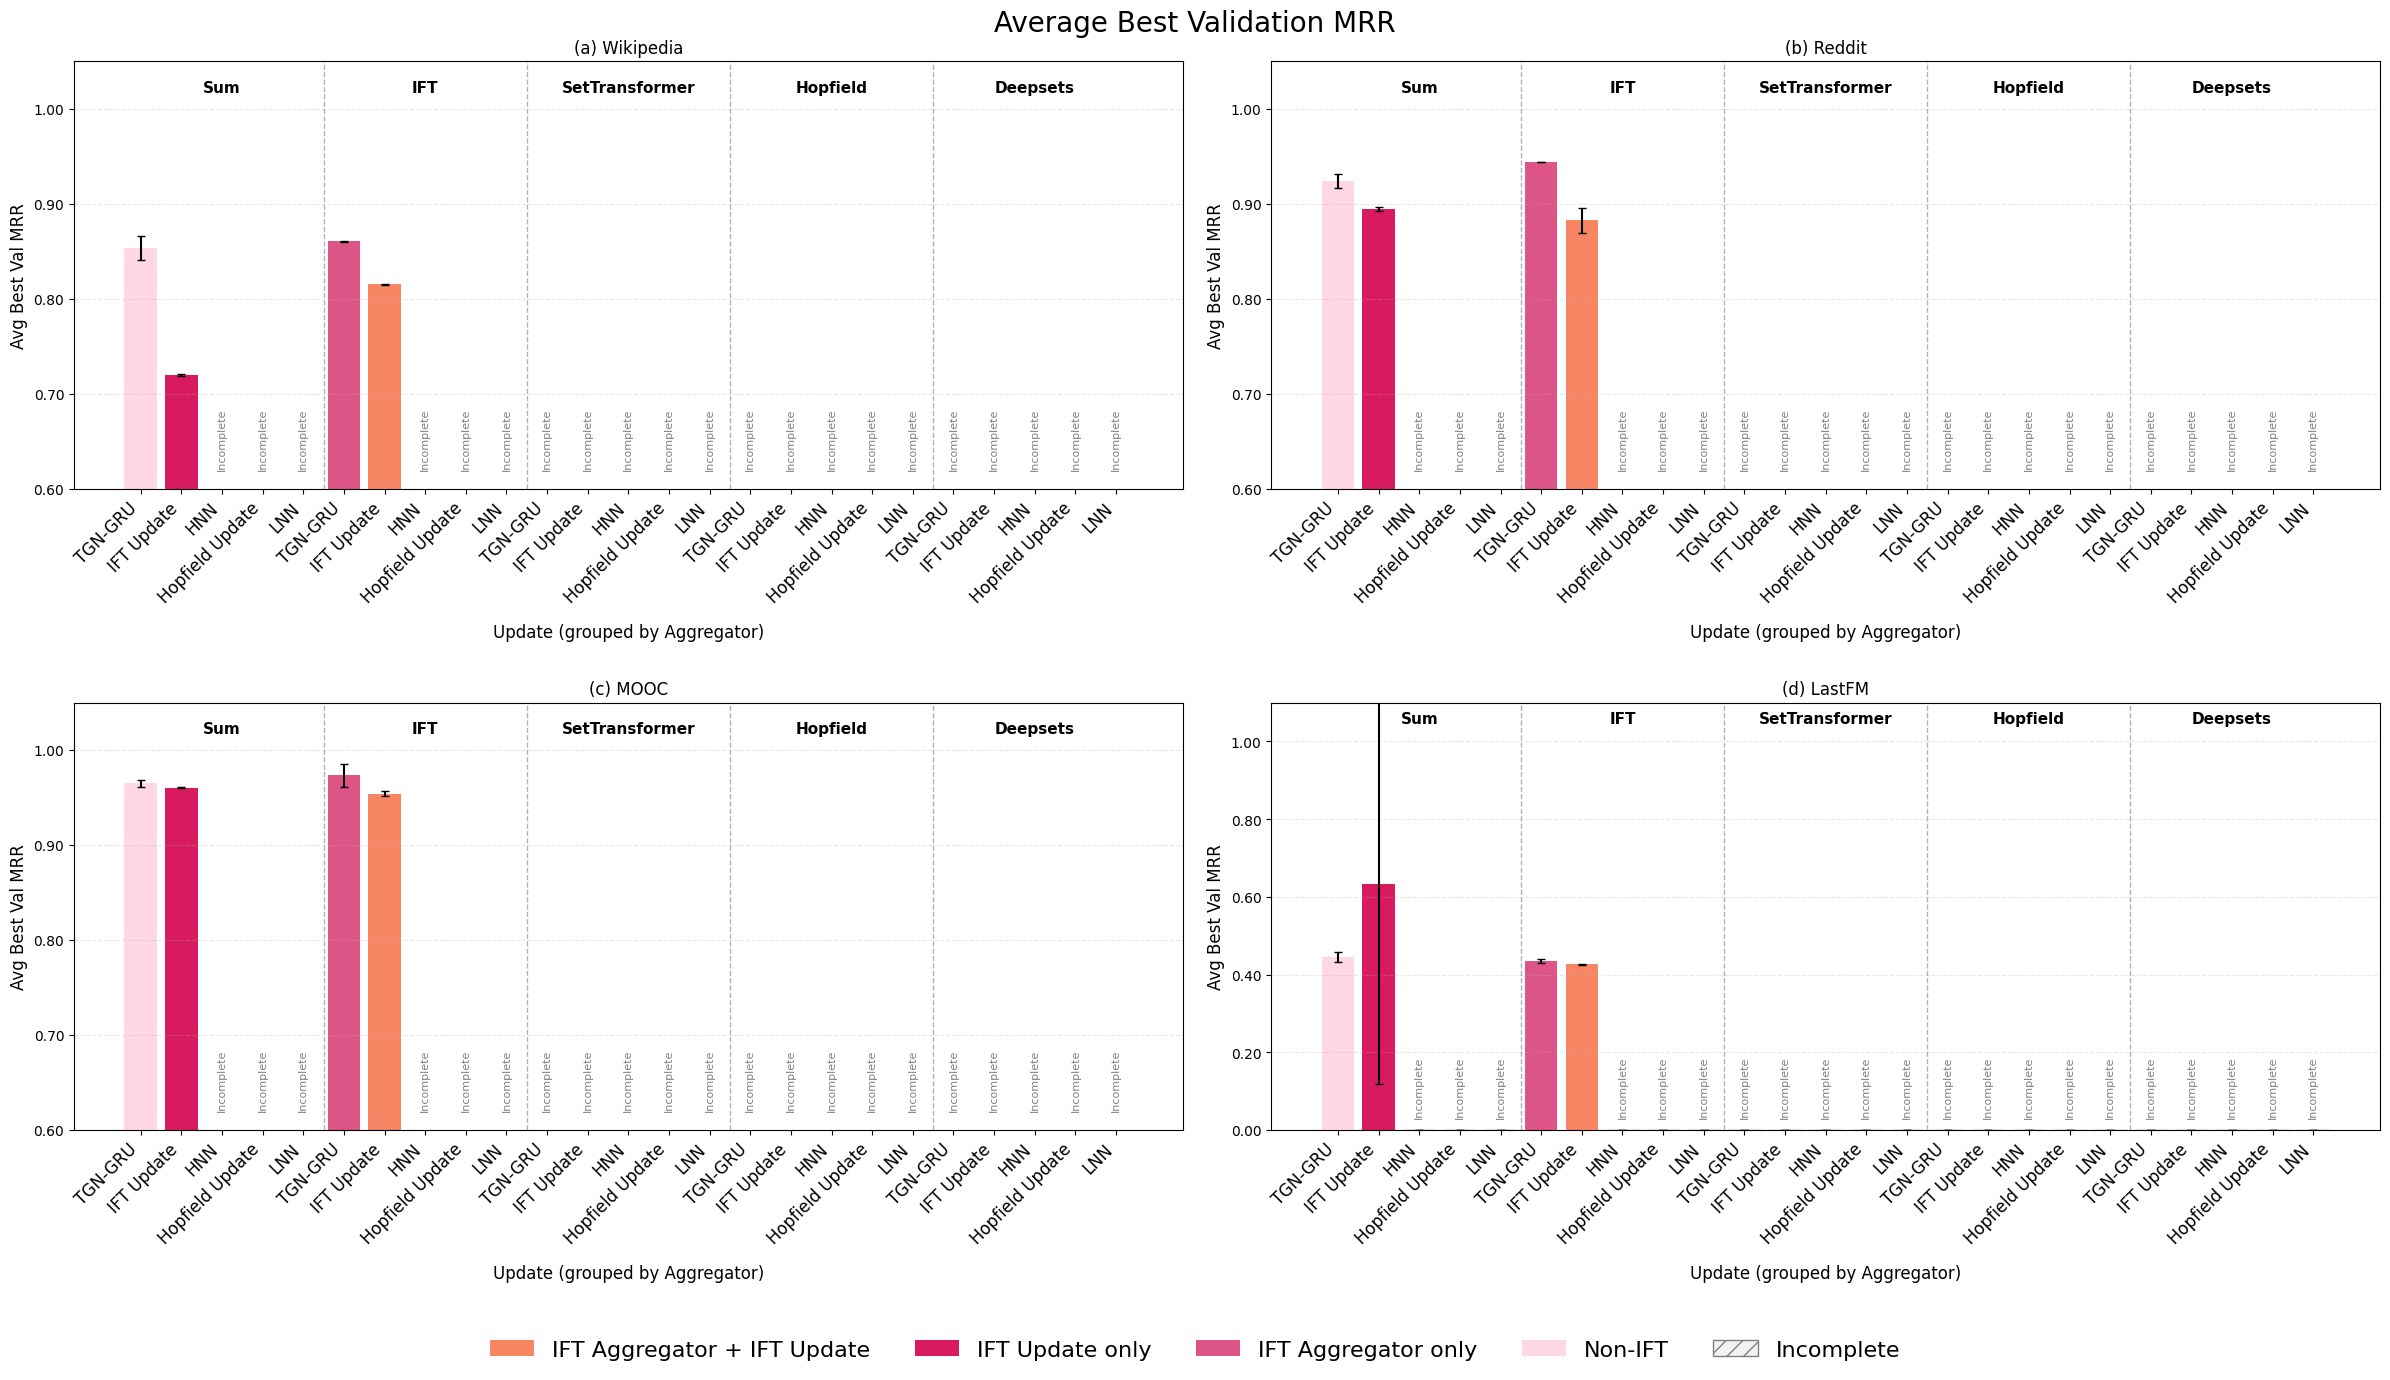

In [ ]:
from matplotlib.patches import Patch
from matplotlib.ticker import FormatStrFormatter

fig, axes = plt.subplots(2, 2, figsize=(24, 14), sharey=False)
axes = axes.flatten()

AGG_ORDER = ["sum", "ift", "settransformer", "hopfield", "deepsets"]
UPD_ORDER = ["tgn_gru", "ift_update", "hnn", "hopfield_update", "lnn"]
def pretty_upd(u):
    return {
        "tgn_gru": "TGN-GRU",
        "lnn": "LNN",
        "hnn": "HNN",
        "hopfield_update": "Hopfield Update",
        "ift_update": "IFT Update",
    }.get(u, u)
def pretty_name(agg, upd):
    agg_map = {
        "sum": "Sum",
        "deepsets": "DeepSets",
        "settransformer": "SetTransformer",
        "hopfield": "Hopfield",
        "ift": "IFT",
    }
    upd_map = {
        "tgn_gru": "TGN-GRU",
        "lnn": "LNN",
        "hnn": "HNN",
        "hopfield_update": "Hopfield Update",
        "ift_update": "IFT Update",
    }
    return f"{agg_map.get(agg, agg)} / {upd_map.get(upd, upd)}"

labels_abcd = ["(a)", "(b)", "(c)", "(d)"]

# full expected combo grid
full_index = pd.MultiIndex.from_product(
    [AGG_ORDER, UPD_ORDER],
    names=["aggregator", "update"]
)
full_df = pd.DataFrame(index=full_index).reset_index()

for ax, ds, panel_label in zip(axes, DATASET_ORDER, labels_abcd):
    focus_df = rank_all_by_dataset[ds].copy()

    # merge actual results onto full combo list
    df_full = full_df.merge(focus_df, on=["aggregator", "update"], how="left")

    # preserve explicit ordering
    df_full["aggregator"] = pd.Categorical(df_full["aggregator"], categories=AGG_ORDER, ordered=True)
    df_full["update"] = pd.Categorical(df_full["update"], categories=UPD_ORDER, ordered=True)
    df_full = df_full.sort_values(["aggregator", "update"]).reset_index(drop=True)

    x = np.arange(len(df_full))
    y = df_full["avg_val_mrr"].values
    err = df_full["std_val_mrr"].fillna(0).values
    labels = [pretty_upd(u) for u in df_full["update"]]

    # missing bars should still occupy space
    bar_heights = np.nan_to_num(y, nan=0.0)

    bars = ax.bar(x, bar_heights, yerr=err, capsize=3)

    for i, (bar, upd, agg, val) in enumerate(zip(bars, df_full["update"], df_full["aggregator"], y)):
        if pd.isna(val):
            # incomplete combo
            bar.set_facecolor("#f2f2f2")
            bar.set_edgecolor("gray")
            bar.set_hatch("//")
            bar.set_linewidth(1.0)

            # mark incomplete above baseline
            ax.text(
                i, 0.62 if ds in ["Wikipedia", "Reddit", "MOOC"] else 0.03,
                "Incomplete",
                rotation=90,
                ha="center",
                va="bottom",
                fontsize=8,
                color="gray"
            )
        else:
            if (upd == "ift_update") and (agg == "ift"):
                bar.set_facecolor("#f88664")
            elif upd == "ift_update":
                bar.set_facecolor("#d81b60")
            elif agg == "ift":
                bar.set_facecolor("#dd5486")
            else:
                bar.set_facecolor("#ffd7e5")

    # separator lines between aggregator groups
    for boundary in [4.5, 9.5, 14.5, 19.5]:
        ax.axvline(boundary, color="gray", linestyle="--", linewidth=1, alpha=0.6)

    # optional group labels centered over each block of 5
    group_centers = [2, 7, 12, 17, 22]
    group_names = ["Sum", "IFT", "SetTransformer", "Hopfield", "Deepsets"]
    for xc, gname in zip(group_centers, group_names):
        ax.text(
            xc,
            1.015 if ds in ["Wikipedia", "Reddit", "MOOC"] else 1.04,
            gname,
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

    ax.set_title(f"{panel_label} {ds}")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=12)
    ax.set_ylabel("Avg Best Val MRR", fontsize=12)
    ax.set_xlabel("Update (grouped by Aggregator)", fontsize=12, labelpad=12)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    if ds in ["Wikipedia", "Reddit", "MOOC"]:
        ax.set_ylim(0.6, 1.05)
    elif ds == "LastFM":
        ax.set_ylim(0.0, 1.1)

legend_elements = [
    Patch(facecolor="#f88664", label="IFT Aggregator + IFT Update"),
    Patch(facecolor="#d81b60", label="IFT Update only"),
    Patch(facecolor="#dd5486", label="IFT Aggregator only"),
    Patch(facecolor="#ffd7e5", label="Non-IFT"),
    Patch(facecolor="#f2f2f2", edgecolor="gray", hatch="//", label="Incomplete"),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=5,
    frameon=False,
    fontsize=16
)

fig.suptitle("Average Best Validation MRR", fontsize=20)
fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.subplots_adjust(
    hspace=0.5,   # vertical spacing between rows
    wspace=0.08    # horizontal spacing between columns
)
fig.savefig(PLOTS_DIR / "grouped_by_aggregator_bar_with_incomplete.png", dpi=300, bbox_inches="tight")
plt.show()

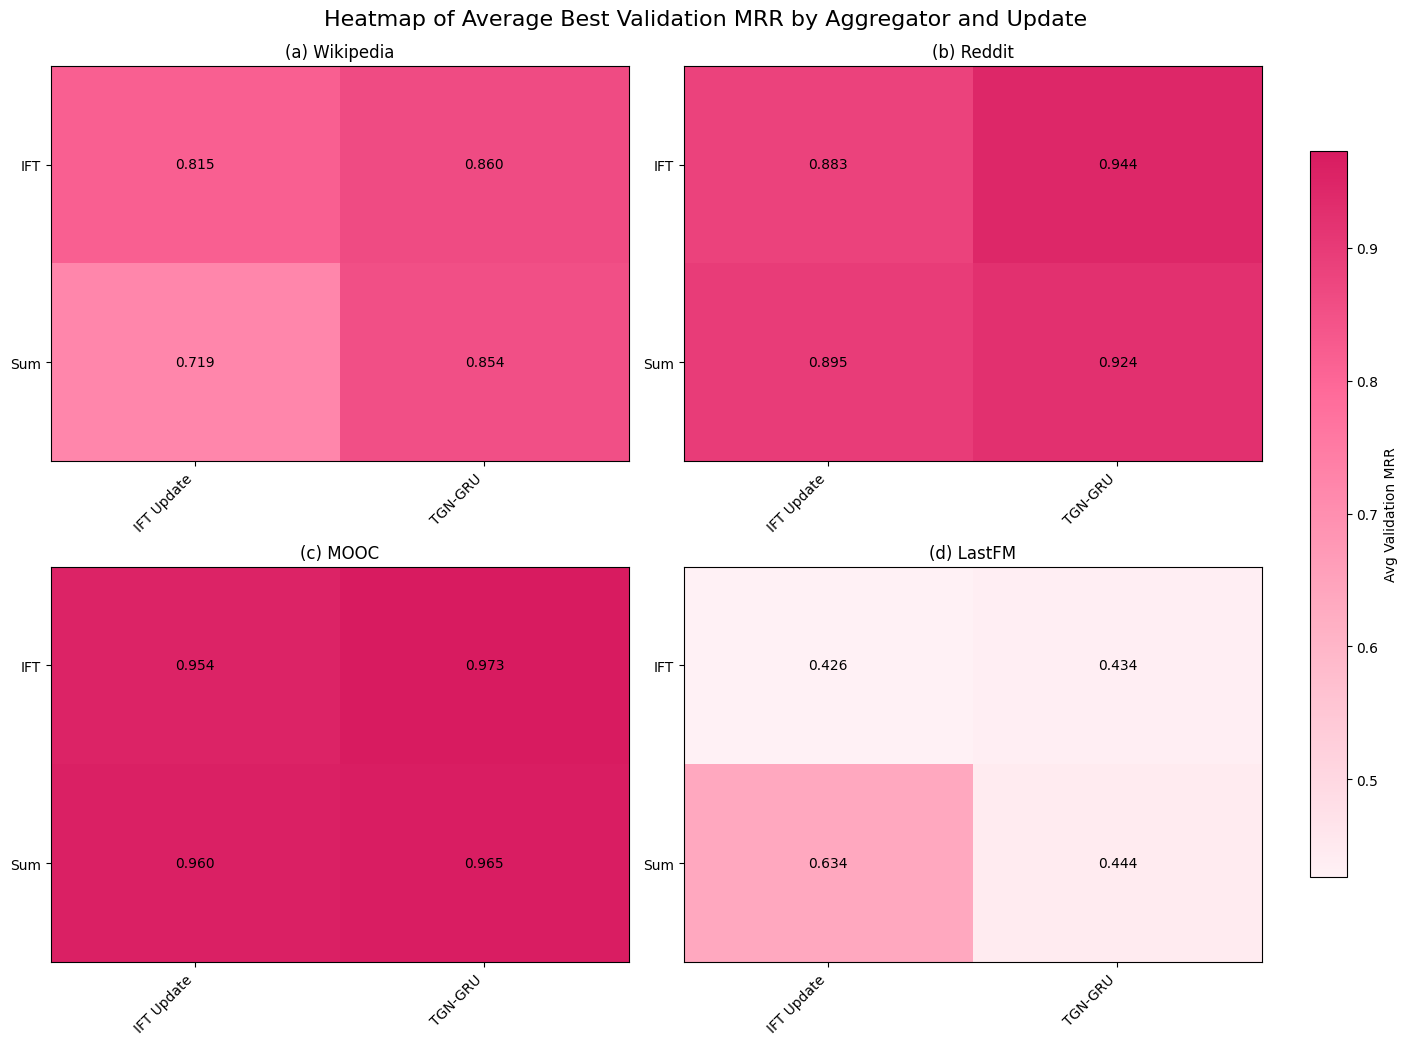

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

def pretty_agg(a):
    return {
        "sum": "Sum",
        "deepsets": "DeepSets",
        "settransformer": "SetTransformer",
        "hopfield": "Hopfield",
        "ift": "IFT",
    }.get(a, a)

def pretty_upd(u):
    return {
        "tgn_gru": "TGN-GRU",
        "lnn": "LNN",
        "hnn": "HNN",
        "hopfield_update": "Hopfield Update",
        "ift_update": "IFT Update",
    }.get(u, u)

# custom pink colormap
pink_cmap = LinearSegmentedColormap.from_list(
    "pinkmap",
    ["#fff1f5", "#ffb3c6", "#ff6b9a", "#d81b60"]
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axes = axes.flatten()

labels = ["(a)", "(b)", "(c)", "(d)"]

global_vmin = plot_df["avg_val_mrr"].min()
global_vmax = plot_df["avg_val_mrr"].max()

for ax, ds, label in zip(axes, DATASET_ORDER, labels):

    focus_df = rank_all_by_dataset[ds].copy()

    heat = focus_df.pivot(
        index="aggregator",
        columns="update",
        values="avg_val_mrr"
    )

    im = ax.imshow(
        heat.values,
        aspect="auto",
        vmin=global_vmin,
        vmax=global_vmax,
        cmap=pink_cmap
    )

    ax.set_title(f"{label} {ds}")

    # prettier labels
    clean_updates = [pretty_upd(c) for c in heat.columns]
    clean_aggs = [pretty_agg(a) for a in heat.index]

    ax.set_xticks(np.arange(len(heat.columns)))
    ax.set_xticklabels(clean_updates, rotation=45, ha="right")

    ax.set_yticks(np.arange(len(heat.index)))
    ax.set_yticklabels(clean_aggs)
    # annotate cells
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            val = heat.values[i, j]
            if pd.notna(val):
                text = f"{val:.3f}"
                color = "black"
                size = 10
            else:
                text = "☠️"
                size = 20

            ax.text(
                j, i,
                text,
                ha="center",
                va="center",
                fontsize=size,
                color=color
            )
                

# put colorbar on the right side of the figure
cbar = fig.colorbar(
    im,
    ax=axes,
    location="right",
    fraction=0.03,
    pad=0.04
)

cbar.set_label("Avg Validation MRR")

fig.suptitle("Heatmap of Average Best Validation MRR by Aggregator and Update", fontsize=16, y=1.03)
fig.savefig(
    PLOTS_DIR / "heatmap_avg_val_mrr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

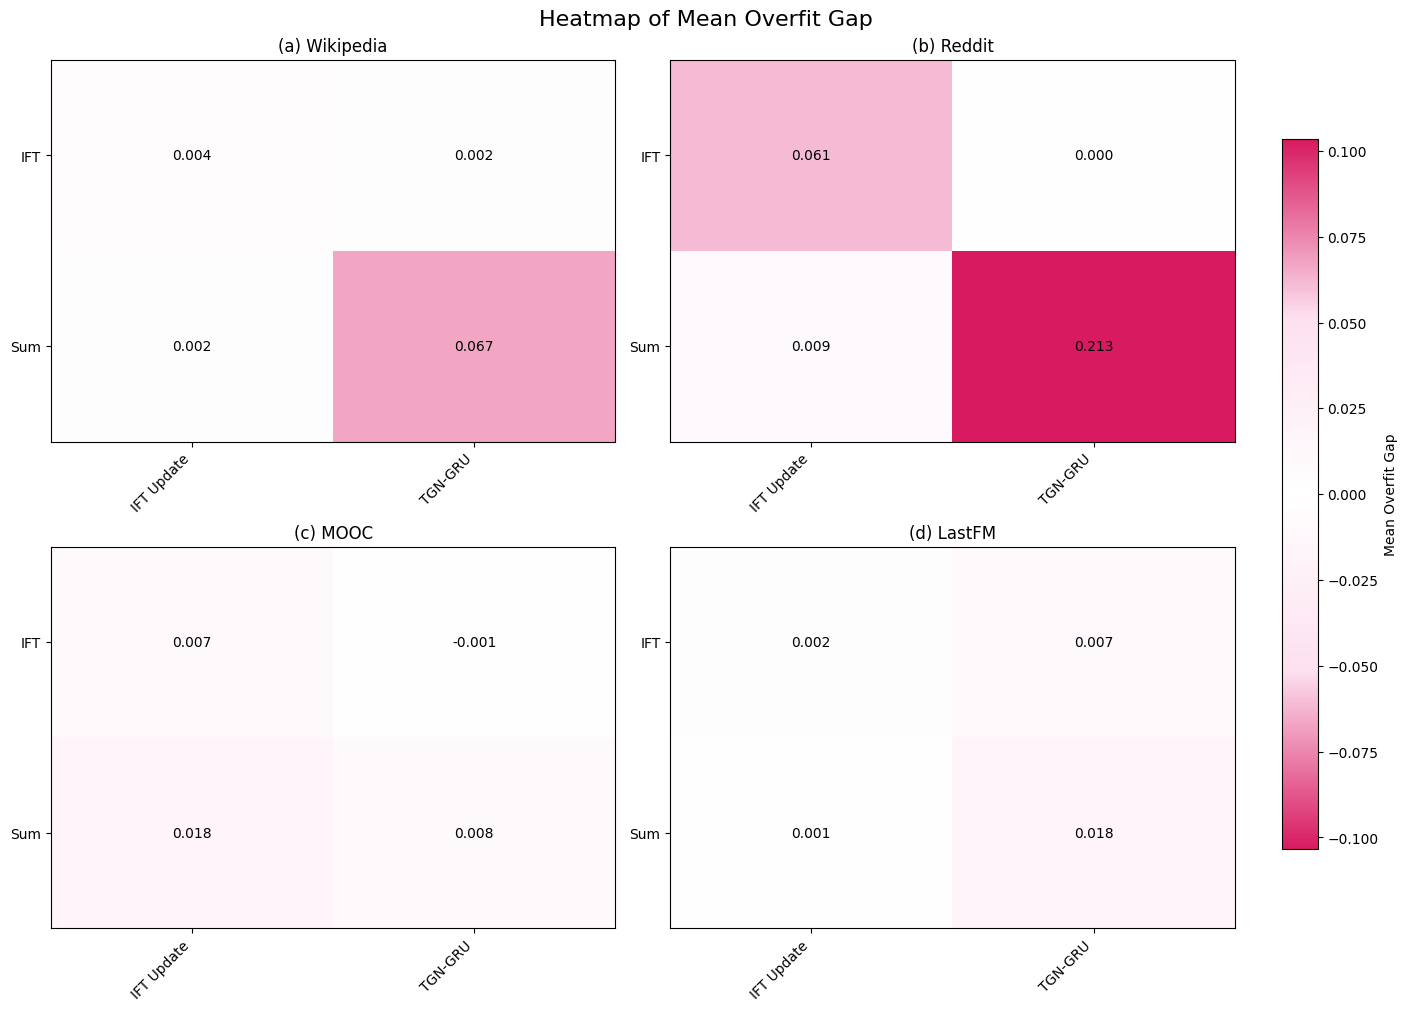

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

# 🔹 pretty names (same as before)
def pretty_agg(a):
    return {
        "sum": "Sum",
        "deepsets": "DeepSets",
        "settransformer": "SetTransformer",
        "hopfield": "Hopfield",
        "ift": "IFT",
    }.get(a, a)

def pretty_upd(u):
    return {
        "tgn_gru": "TGN-GRU",
        "lnn": "LNN",
        "hnn": "HNN",
        "hopfield_update": "Hopfield Update",
        "ift_update": "IFT Update",
    }.get(u, u)

# 🔥 diverging pink colormap (negative → light, positive → dark)
diverging_pink = LinearSegmentedColormap.from_list(
    "diverging_pink",
    ["#d81b60", "#fde0ef", "#ffffff", "#fde0ef", "#d81b60"]  # light pink → white → dark pink
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axes = axes.flatten()

labels = ["(a)", "(b)", "(c)", "(d)"]

# 🔹 symmetric scale around 0
absmax = np.nanpercentile(
    np.abs(plot_df["mean_overfit_gap"].values),
    95   # or 90 if you want stronger clipping
)
global_vmin = -absmax
global_vmax = absmax

for ax, ds, label in zip(axes, DATASET_ORDER, labels):

    focus_df = rank_all_by_dataset[ds].copy()

    heat = focus_df.pivot(
        index="aggregator",
        columns="update",
        values="mean_overfit_gap"
    )

    im = ax.imshow(
        heat.values,
        aspect="auto",
        vmin=global_vmin,
        vmax=global_vmax,
        cmap=diverging_pink
    )

    ax.set_title(f"{label} {ds}")

    # ✅ same pretty labels
    clean_updates = [pretty_upd(c) for c in heat.columns]
    clean_aggs = [pretty_agg(a) for a in heat.index]

    ax.set_xticks(np.arange(len(heat.columns)))
    ax.set_xticklabels(clean_updates, rotation=45, ha="right")

    ax.set_yticks(np.arange(len(heat.index)))
    ax.set_yticklabels(clean_aggs)

    # 🔹 annotate cells
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            val = heat.values[i, j]

            if pd.notna(val):
                text = f"{val:.3f}"

                # white text on darker cells
                color = "black"
                size = 10
            else:
                text = "☠️"
                color = "black"
                size = 16

            ax.text(
                j, i,
                text,
                ha="center",
                va="center",
                fontsize=size,
                color=color
            )

# 🔹 clean colorbar (RIGHT SIDE, same as before)
cbar = fig.colorbar(
    im,
    ax=axes,
    location="right",
    fraction=0.03,
    pad=0.04
)

cbar.set_label("Mean Overfit Gap")

fig.suptitle(
    "Heatmap of Mean Overfit Gap",
    fontsize=16
)

fig.savefig(
    PLOTS_DIR / "heatmap_mean_overfit_gap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

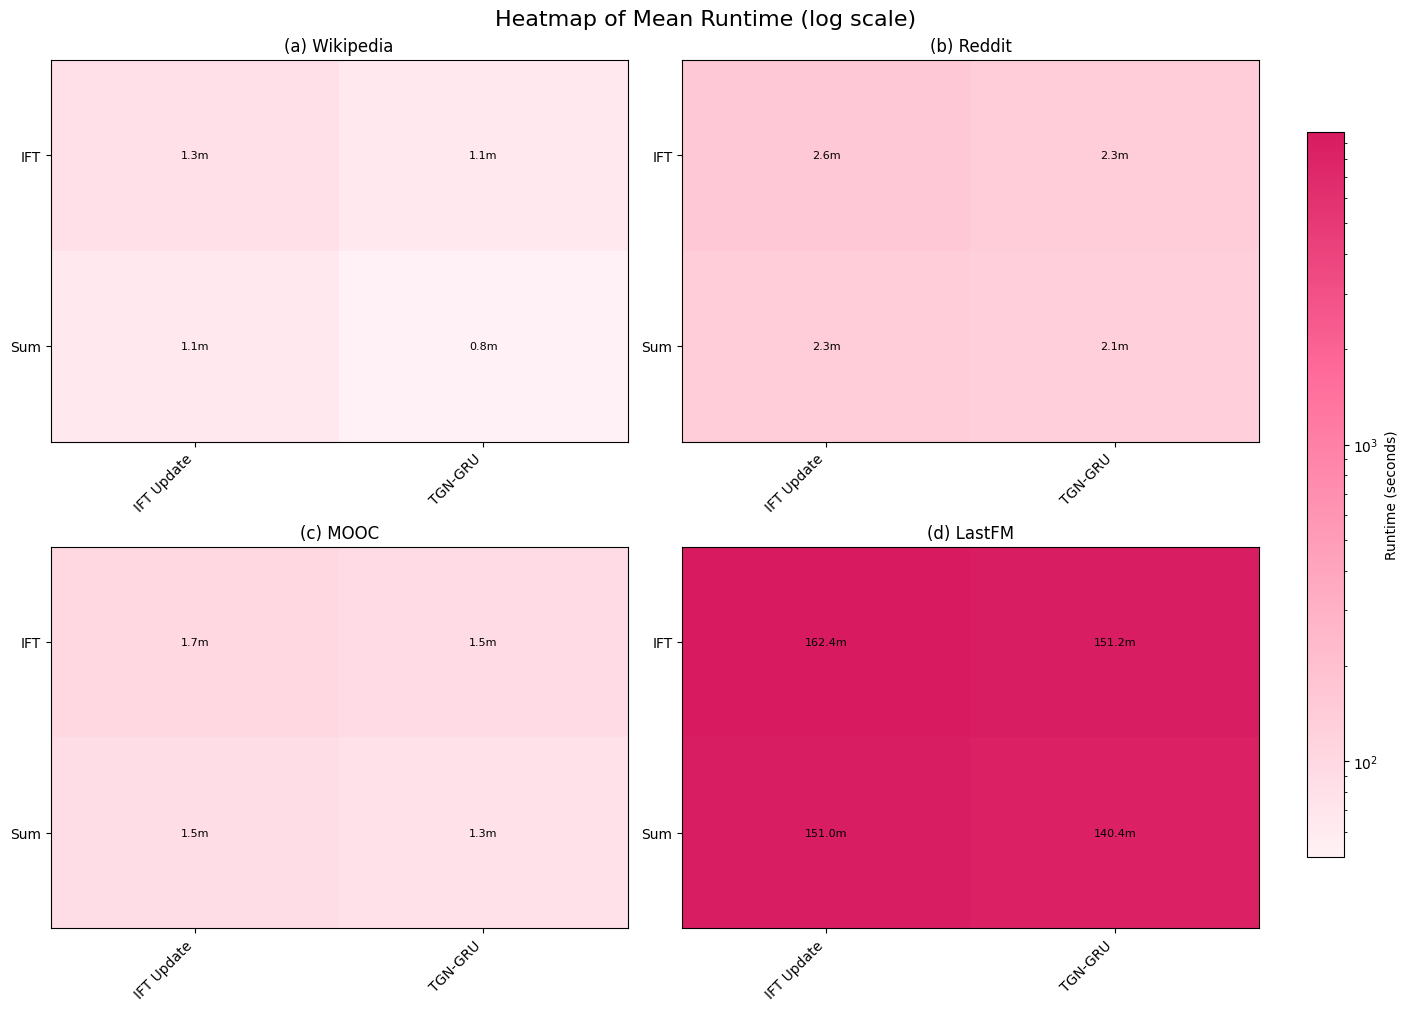

In [ ]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as colors

# 🔹 pretty names (reuse)
def pretty_agg(a):
    return {
        "sum": "Sum",
        "deepsets": "DeepSets",
        "settransformer": "SetTransformer",
        "hopfield": "Hopfield",
        "ift": "IFT",
    }.get(a, a)

def pretty_upd(u):
    return {
        "tgn_gru": "TGN-GRU",
        "lnn": "LNN",
        "hnn": "HNN",
        "hopfield_update": "Hopfield Update",
        "ift_update": "IFT Update",
    }.get(u, u)

# 💖 sequential pink colormap (low → high runtime)
pink_cmap = LinearSegmentedColormap.from_list(
    "pink_runtime",
    ["#fff1f5", "#ffb3c6", "#ff6b9a", "#d81b60"]
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axes = axes.flatten()

labels = ["(a)", "(b)", "(c)", "(d)"]

# 🔹 global scale (keeps comparison fair)
global_vmin = plot_df["wall_sec_mean"].min()
global_vmax = plot_df["wall_sec_mean"].max()

for ax, ds, label in zip(axes, DATASET_ORDER, labels):

    focus_df = rank_all_by_dataset[ds].copy()

    heat = focus_df.pivot(
        index="aggregator",
        columns="update",
        values="wall_sec_mean"
    )

    im = ax.imshow(
        heat.values,
        norm=colors.LogNorm(vmin=global_vmin, vmax=global_vmax),
        cmap=pink_cmap,
        aspect="auto"
    )

    ax.set_title(f"{label} {ds}")

    # ✅ consistent pretty labels
    clean_updates = [pretty_upd(c) for c in heat.columns]
    clean_aggs = [pretty_agg(a) for a in heat.index]

    ax.set_xticks(np.arange(len(heat.columns)))
    ax.set_xticklabels(clean_updates, rotation=45, ha="right")

    ax.set_yticks(np.arange(len(heat.index)))
    ax.set_yticklabels(clean_aggs)

    # 🔹 annotate (minutes, black text only)
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            val = heat.values[i, j]

            if pd.notna(val):
                text = f"{val/60:.1f}m"   # convert sec → minutes
                size = 8
            else:
                text = "☠️"
                size = 16

            ax.text(
                j, i,
                text,
                ha="center",
                va="center",
                fontsize=size,
                color="black"
            )

# 🔹 clean right-side colorbar
cbar = fig.colorbar(
    im,
    ax=axes,
    location="right",
    fraction=0.03,
    pad=0.04
)

cbar.set_label("Runtime (seconds)")

fig.suptitle(
    "Heatmap of Mean Runtime (log scale)",
    fontsize=16
)

fig.savefig(
    PLOTS_DIR / "heatmap_runtime.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

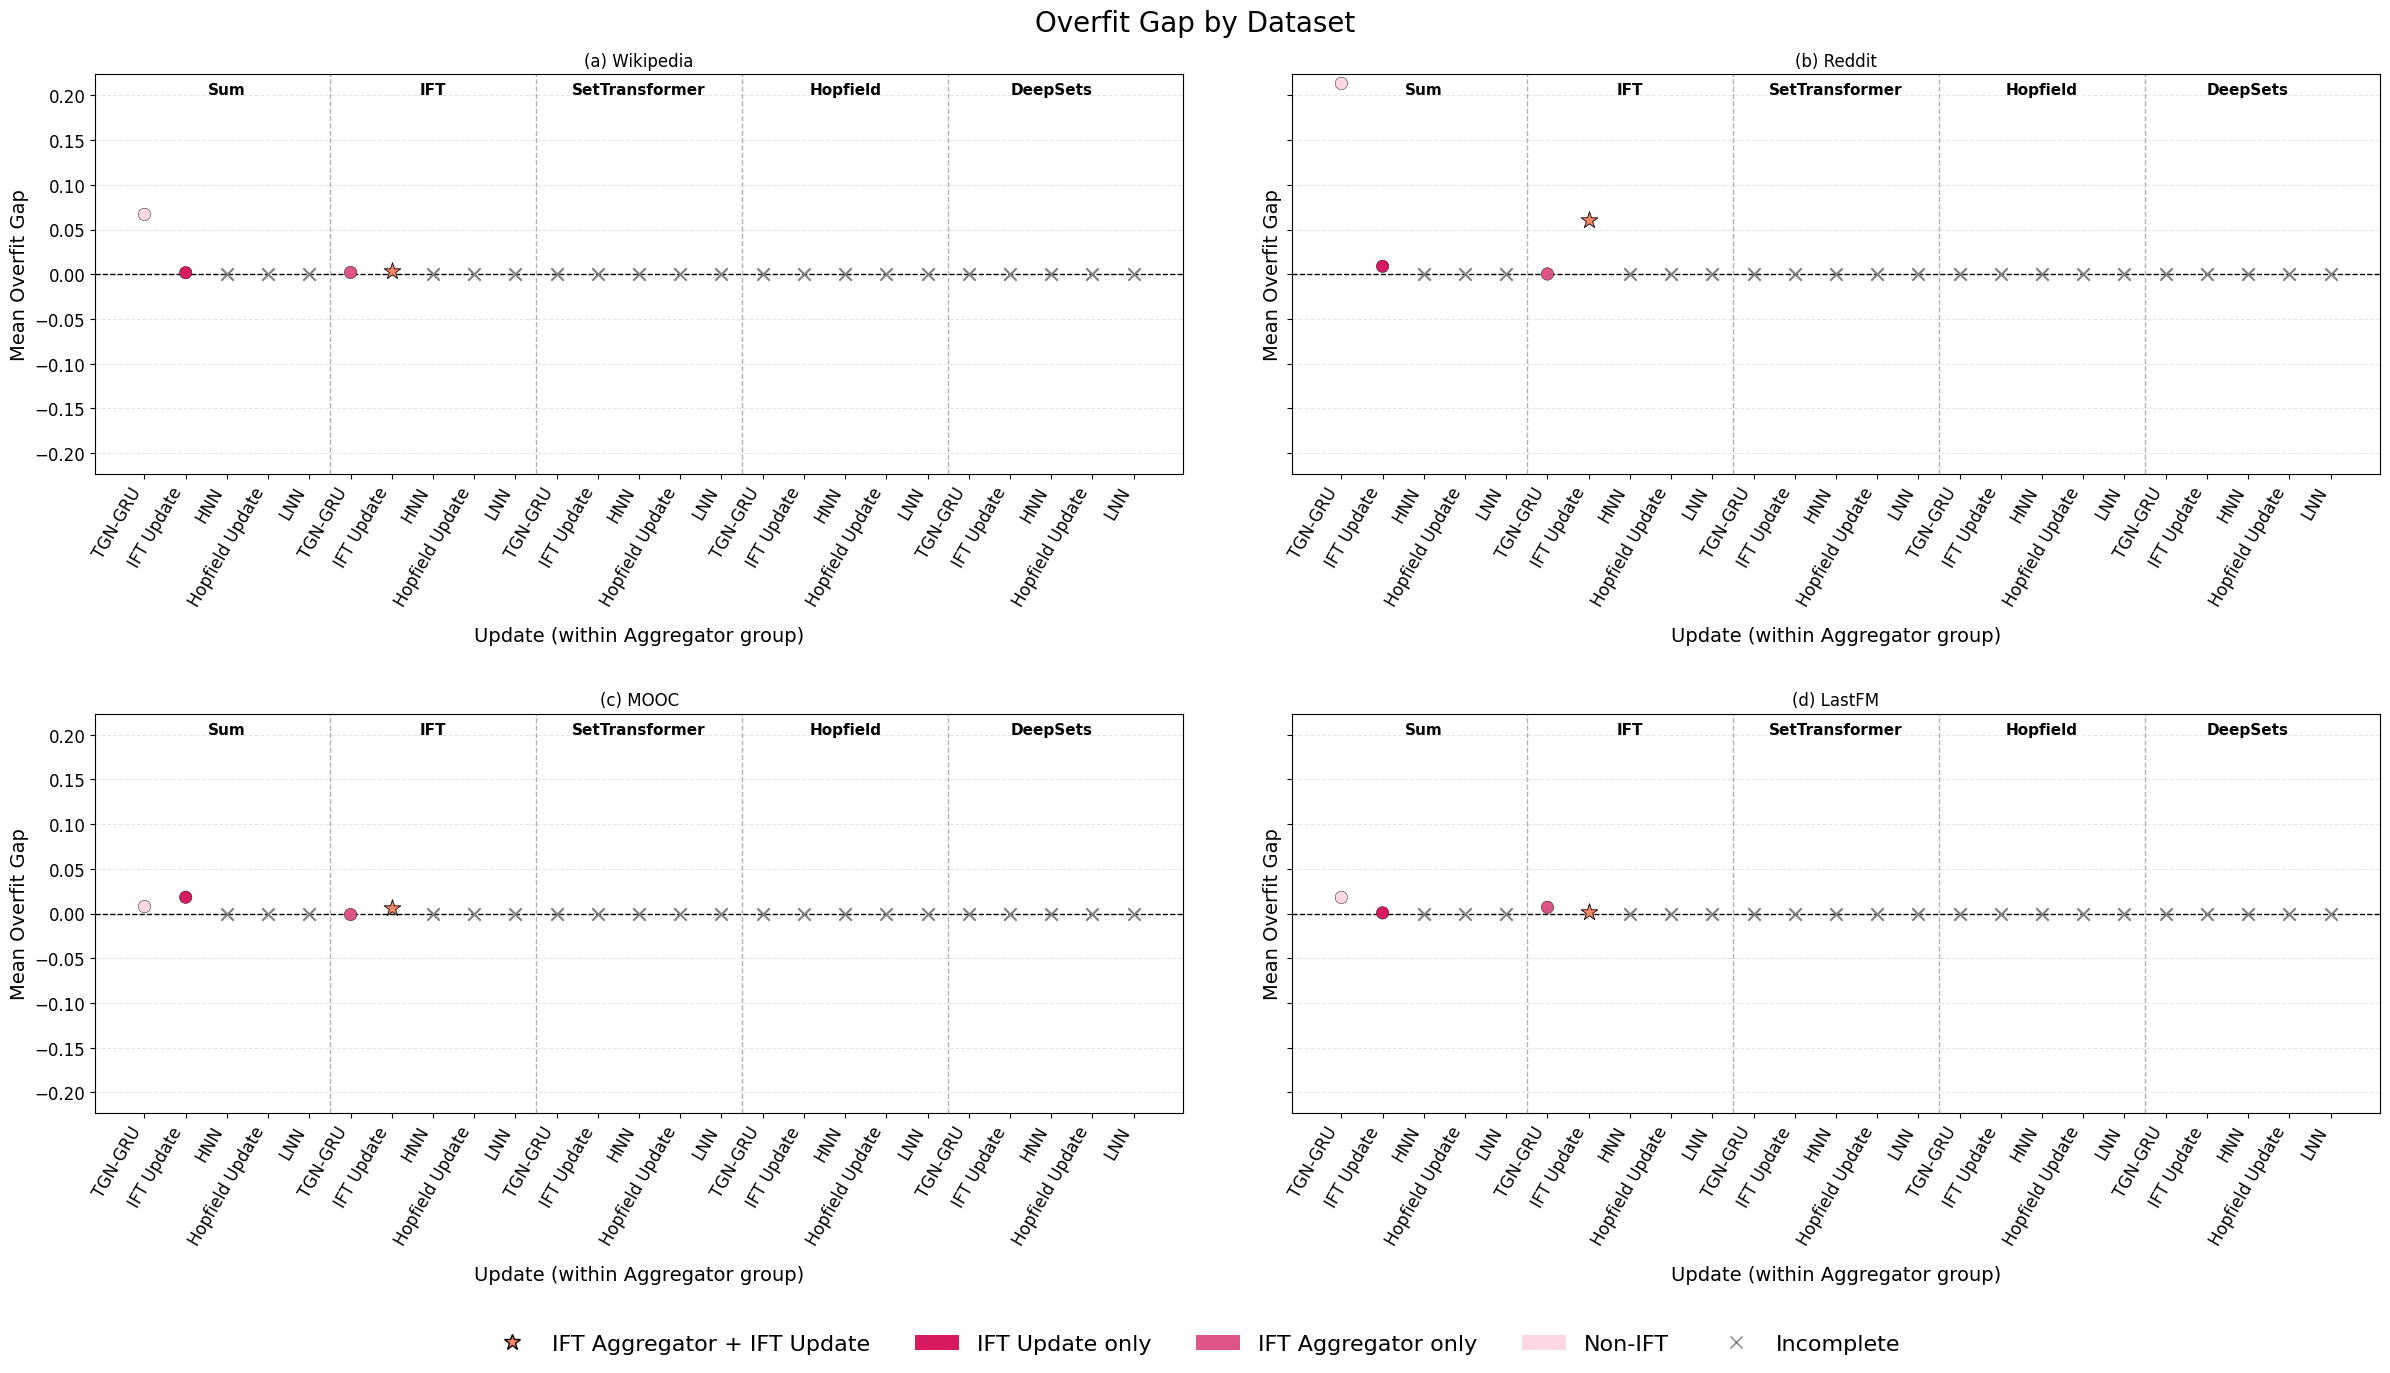

In [ ]:
from matplotlib.patches import Patch
from matplotlib.ticker import FormatStrFormatter
from matplotlib.lines import Line2D
def pretty_agg(a):
    return {
        "sum": "Sum",
        "deepsets": "DeepSets",
        "settransformer": "SetTransformer",
        "hopfield": "Hopfield",
        "ift": "IFT",
    }.get(a, a)

def pretty_upd(u):
    return {
        "tgn_gru": "TGN-GRU",
        "lnn": "LNN",
        "hnn": "HNN",
        "hopfield_update": "Hopfield Update",
        "ift_update": "IFT Update",
    }.get(u, u)

AGG_ORDER = ["sum", "ift", "settransformer", "hopfield", "deepsets"]
UPD_ORDER = ["tgn_gru", "ift_update", "hnn", "hopfield_update", "lnn"]

fig, axes = plt.subplots(2, 2, figsize=(24, 15), sharey=True)
axes = axes.flatten()

labels_abcd = ["(a)", "(b)", "(c)", "(d)"]

absmax = np.nanmax(np.abs(plot_df["mean_overfit_gap"].values))
ymin, ymax = -absmax - 0.01, absmax + 0.01

# full combo grid so missing combos still appear
full_index = pd.MultiIndex.from_product(
    [AGG_ORDER, UPD_ORDER],
    names=["aggregator", "update"]
)
full_df = pd.DataFrame(index=full_index).reset_index()

for ax, ds, panel_label in zip(axes, DATASET_ORDER, labels_abcd):
    focus_df = rank_all_by_dataset[ds].copy()

    # merge onto full combo grid
    df_full = full_df.merge(focus_df, on=["aggregator", "update"], how="left")

    df_full["aggregator"] = pd.Categorical(
        df_full["aggregator"], categories=AGG_ORDER, ordered=True
    )
    df_full["update"] = pd.Categorical(
        df_full["update"], categories=UPD_ORDER, ordered=True
    )
    df_full = df_full.sort_values(["aggregator", "update"]).reset_index(drop=True)

    x = np.arange(len(df_full))
    y = df_full["mean_overfit_gap"].values
    labels = [pretty_upd(u) for u in df_full["update"]]

    colors = [
        "#f88664" if (u == "ift_update" and a == "ift")
        else "#d81b60" if (u == "ift_update")
        else "#dd5486" if (a == "ift")
        else "#ffd7e5"
        for a, u in zip(df_full["aggregator"], df_full["update"])
    ]

    # plot completed points
    mask = pd.notna(y)
    # identify special combo
    is_star = (df_full["aggregator"] == "ift") & (df_full["update"] == "ift_update")
    is_star = is_star.values & mask

    # normal points
    normal_mask = mask & ~is_star

    ax.scatter(
        x[normal_mask],
        y[normal_mask],
        c=np.array(colors)[normal_mask],
        s=80,
        edgecolors="black",
        linewidth=0.3,
        marker="o",
        zorder=3
    )

    # ⭐ star points
    ax.scatter(
        x[is_star],
        y[is_star],
        c="#f88664",   # same highlight color
        s=160,         # bigger so it stands out
        edgecolors="black",
        linewidth=0.6,
        marker="*",
        zorder=4
    )

    # plot incomplete combos as gray X on the zero line
    incomplete_mask = ~mask
    if incomplete_mask.any():
        ax.scatter(
            x[incomplete_mask],
            np.zeros(incomplete_mask.sum()),
            marker="x",
            s=80,
            color="gray",
            linewidth=1.5,
            zorder=3
        )

    ax.axhline(0, linestyle="--", color="black", linewidth=1)
    ax.set_title(f"{panel_label} {ds}")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=60, ha="right")
    ax.set_ylim(ymin, ymax)
    ax.set_ylabel("Mean Overfit Gap", fontsize=14)
    ax.set_xlabel("Update (within Aggregator group)", fontsize=14, labelpad=12)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

    # separator lines between aggregator groups
    for boundary in [4.5, 9.5, 14.5, 19.5]:
        ax.axvline(boundary, color="gray", linestyle="--", linewidth=1, alpha=0.6)

    # aggregator headers above each block
    group_centers = [2, 7, 12, 17, 22]
    group_names = [pretty_agg(a) for a in AGG_ORDER]

    for xc, gname in zip(group_centers, group_names):
        ax.text(
            xc,
            ymax - 0.02 * (ymax - ymin),   # 👈 inside plot near top
            gname,
            ha="center",
            va="top",
            fontsize=11,
            fontweight="bold"
        )

legend_elements = [
    Line2D([0], [0], marker='*', color='w', markerfacecolor='#f88664', markeredgecolor='black', markersize=12, label="IFT Aggregator + IFT Update"),
    Patch(facecolor="#d81b60", label="IFT Update only"),
    Patch(facecolor="#dd5486", label="IFT Aggregator only"),
    Patch(facecolor="#ffd7e5", label="Non-IFT"),
    Line2D([0], [0], marker="x", color="gray", linestyle="None", markersize=8, label="Incomplete"),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.03),
    ncol=5,
    frameon=False,
    fontsize=16
)

fig.suptitle("Overfit Gap by Dataset", fontsize=20, y=.94)
fig.tight_layout(rect=[0, 0.08, 1, 0.95])
fig.subplots_adjust(
    hspace=0.6,   # vertical spacing between rows
    wspace=0.1    # horizontal spacing between columns
)
fig.savefig(PLOTS_DIR / "overfit_gap_dotplot.png", dpi=300, bbox_inches="tight")
plt.show()

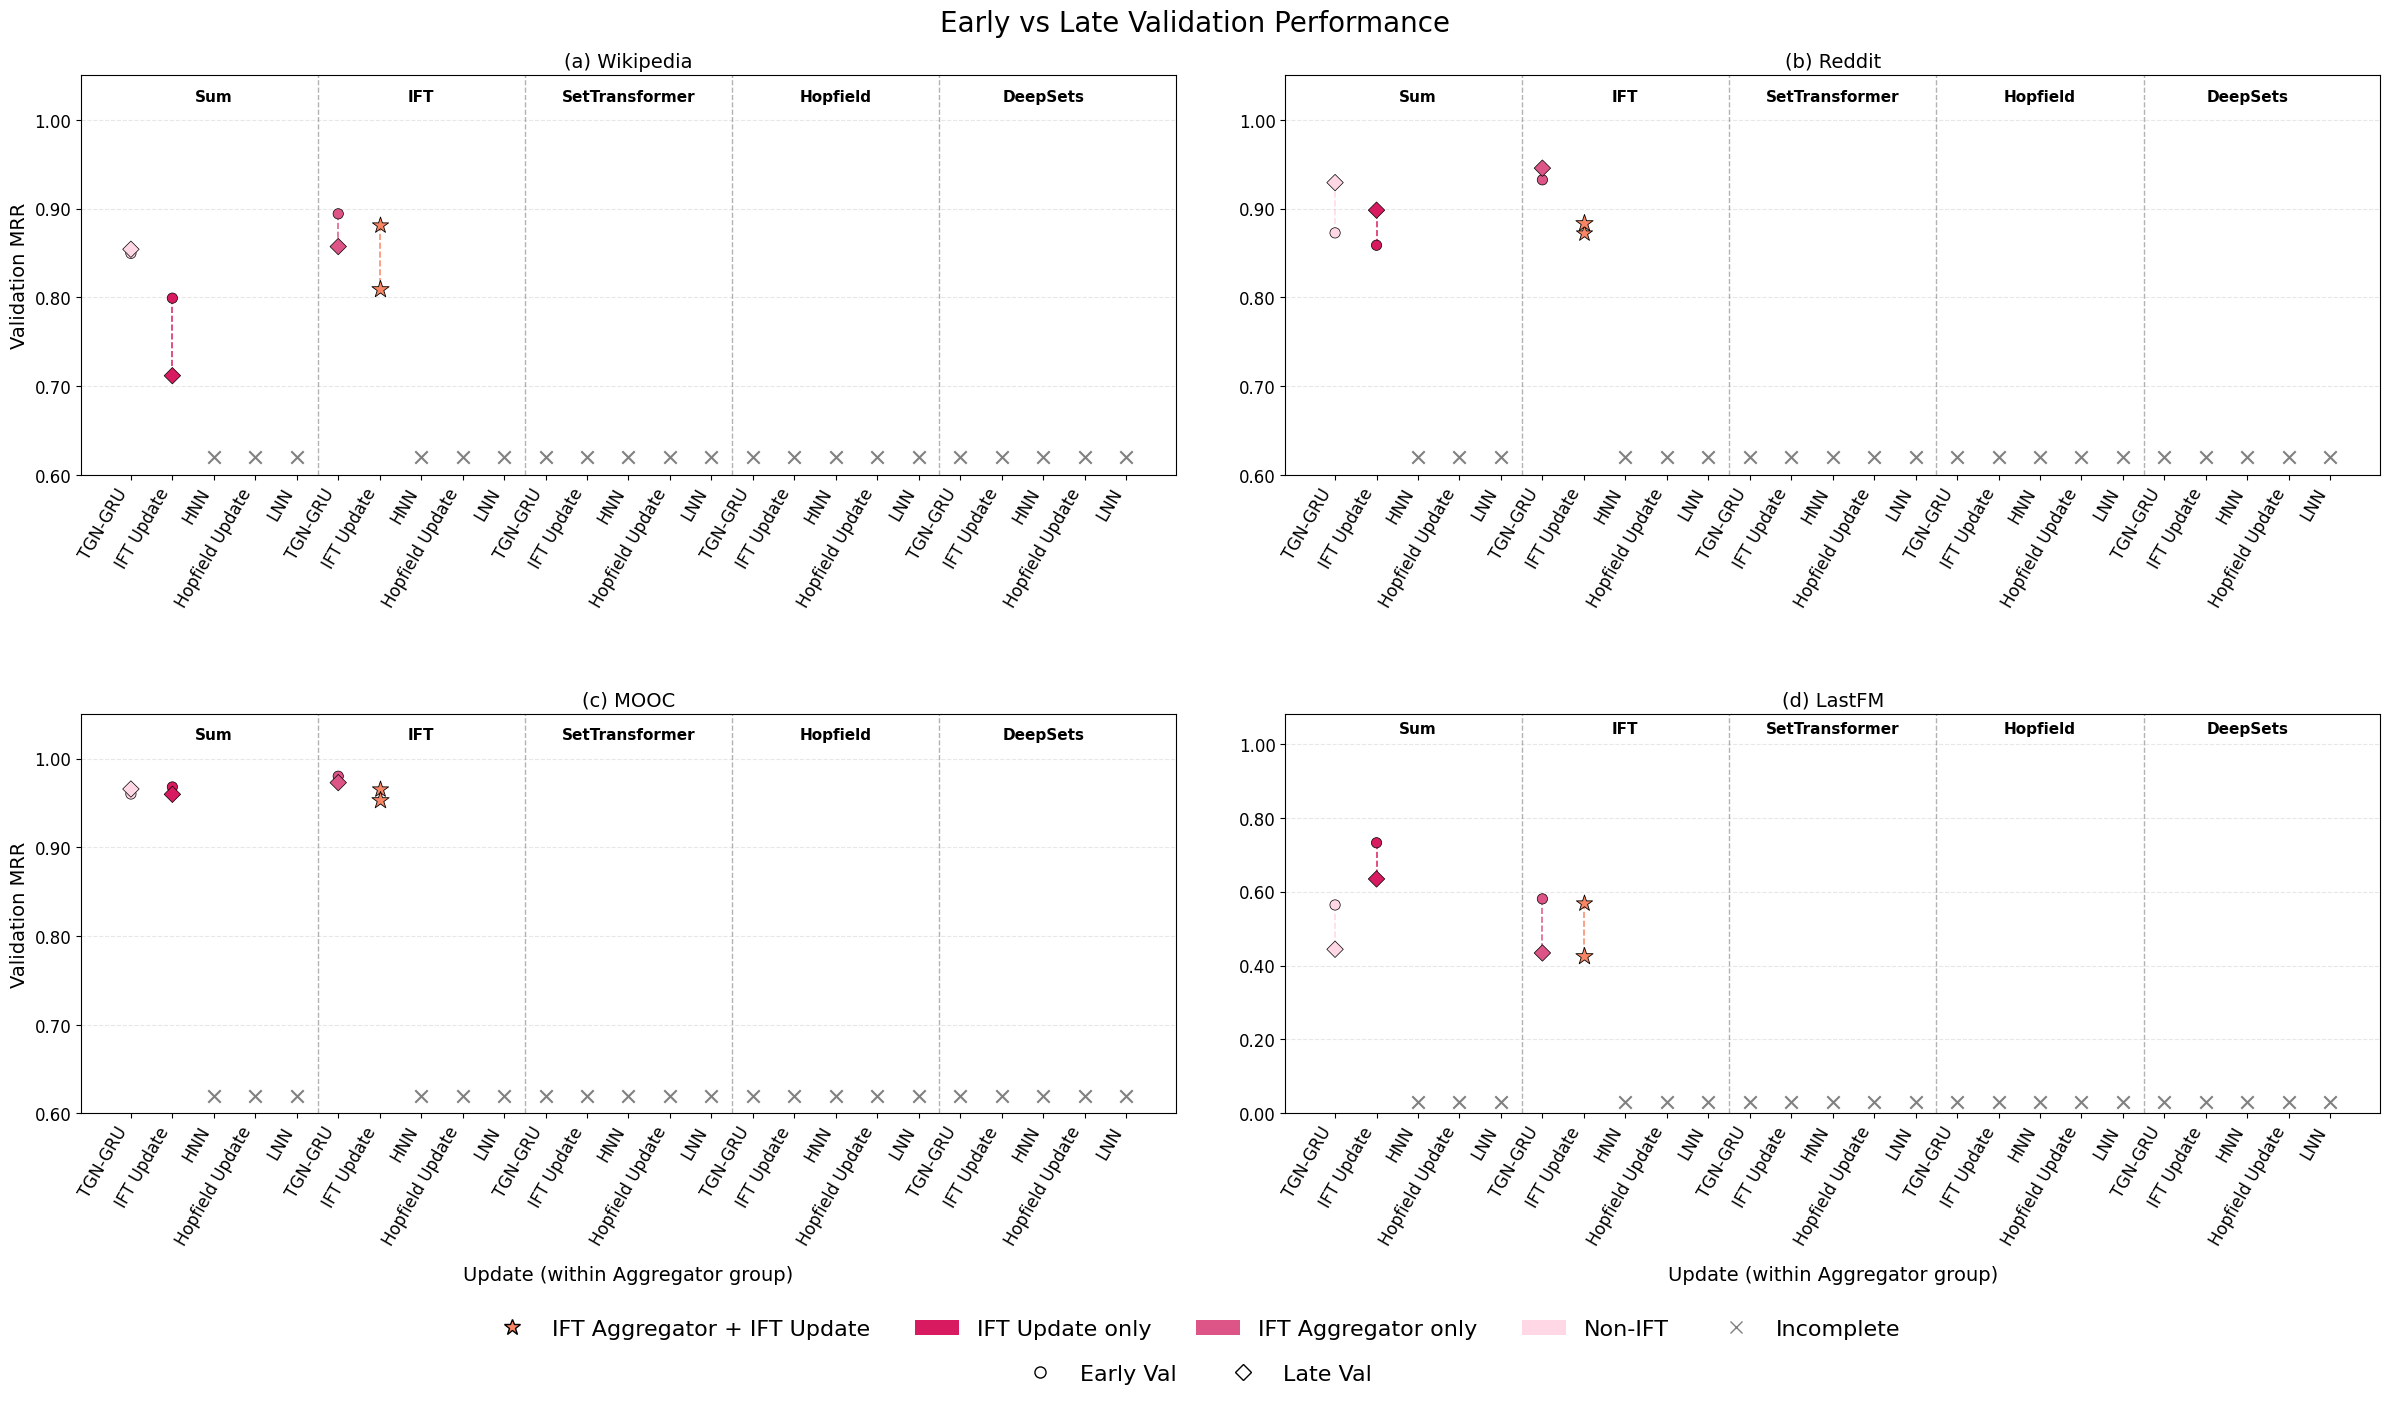

In [ ]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FormatStrFormatter

def pretty_agg(a):
    return {
        "sum": "Sum",
        "deepsets": "DeepSets",
        "settransformer": "SetTransformer",
        "hopfield": "Hopfield",
        "ift": "IFT",
    }.get(a, a)

def pretty_upd(u):
    return {
        "tgn_gru": "TGN-GRU",
        "lnn": "LNN",
        "hnn": "HNN",
        "hopfield_update": "Hopfield Update",
        "ift_update": "IFT Update",
    }.get(u, u)

AGG_ORDER = ["sum", "ift", "settransformer", "hopfield", "deepsets"]
UPD_ORDER = ["tgn_gru", "ift_update", "hnn", "hopfield_update", "lnn"]

fig, axes = plt.subplots(2, 2, figsize=(24, 15), sharey=False)
axes = axes.flatten()

labels_abcd = ["(a)", "(b)", "(c)", "(d)"]

# full combo grid so missing combos still appear
full_index = pd.MultiIndex.from_product(
    [AGG_ORDER, UPD_ORDER],
    names=["aggregator", "update"]
)
full_df = pd.DataFrame(index=full_index).reset_index()

for ax, ds, panel_label in zip(axes, DATASET_ORDER, labels_abcd):
    focus_df = rank_all_by_dataset[ds].copy()

    # merge onto full combo grid
    df_full = full_df.merge(focus_df, on=["aggregator", "update"], how="left")

    df_full["aggregator"] = pd.Categorical(
        df_full["aggregator"], categories=AGG_ORDER, ordered=True
    )
    df_full["update"] = pd.Categorical(
        df_full["update"], categories=UPD_ORDER, ordered=True
    )
    df_full = df_full.sort_values(["aggregator", "update"]).reset_index(drop=True)

    x = np.arange(len(df_full))
    early = df_full["avg_early_val_mrr"].values
    late = df_full["avg_late_val_mrr"].values
    labels = [pretty_upd(u) for u in df_full["update"]]

    combo_colors = [
        "#f88664" if (u == "ift_update" and a == "ift")
        else "#d81b60" if (u == "ift_update")
        else "#dd5486" if (a == "ift")
        else "#ffd7e5"
        for a, u in zip(df_full["aggregator"], df_full["update"])
    ]

    # masks
    early_mask = pd.notna(early)
    late_mask = pd.notna(late)
    complete_mask = early_mask & late_mask

    is_star = (
        (df_full["aggregator"] == "ift") &
        (df_full["update"] == "ift_update")
    ).values

    normal_complete = complete_mask & ~is_star
    star_complete = complete_mask & is_star
    incomplete_mask = ~(early_mask & late_mask)

    # connector lines for complete combos only
    for i in np.where(complete_mask)[0]:
        ax.plot(
            [x[i], x[i]],
            [early[i], late[i]],
            color=combo_colors[i],
            linewidth=1.2,
            linestyle="--",
            alpha=0.9,
            zorder=1
        )

    # normal early points
    ax.scatter(
        x[normal_complete],
        early[normal_complete],
        c=np.array(combo_colors)[normal_complete],
        s=55,
        edgecolors="black",
        linewidth=0.5,
        marker="o",
        zorder=3
    )

    # normal late points
    ax.scatter(
        x[normal_complete],
        late[normal_complete],
        c=np.array(combo_colors)[normal_complete],
        s=70,
        edgecolors="black",
        linewidth=0.5,
        marker="D",
        zorder=3
    )

    # star combo early
    ax.scatter(
        x[star_complete],
        early[star_complete],
        c="#f88664",
        s=150,
        edgecolors="black",
        linewidth=0.6,
        marker="*",
        zorder=4
    )

    # star combo late
    ax.scatter(
        x[star_complete],
        late[star_complete],
        c="#f88664",
        s=170,
        edgecolors="black",
        linewidth=0.6,
        marker="*",
        zorder=4
    )

    # incomplete combos shown as gray X near bottom
    if incomplete_mask.any():
        y_incomplete = np.full(incomplete_mask.sum(), 0.62 if ds in ["Wikipedia", "Reddit", "MOOC"] else 0.03)
        ax.scatter(
            x[incomplete_mask],
            y_incomplete,
            marker="x",
            s=80,
            color="gray",
            linewidth=1.5,
            zorder=3
        )

    # y axis range
    if ds in ["Wikipedia", "Reddit", "MOOC"]:
        ax.set_ylim(0.6, 1.05)
        top_y = 1.035
    elif ds == "LastFM":
        ax.set_ylim(0.0, 1.08)
        top_y = 1.06

    ax.set_title(f"{panel_label} {ds}", fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=60, ha="right")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)

    # only left column y-label
    if ax in [axes[0], axes[2]]:
        ax.set_ylabel("Validation MRR", fontsize=14)
    else:
        ax.set_ylabel("")

    # only bottom row x-label
    if ax in [axes[2], axes[3]]:
        ax.set_xlabel("Update (within Aggregator group)", fontsize=14, labelpad=12)
    else:
        ax.set_xlabel("")

    # separator lines between aggregator groups
    for boundary in [4.5, 9.5, 14.5, 19.5]:
        ax.axvline(boundary, color="gray", linestyle="--", linewidth=1, alpha=0.6)

    # aggregator labels inside plot
    group_centers = [2, 7, 12, 17, 22]
    group_names = [pretty_agg(a) for a in AGG_ORDER]

    for xc, gname in zip(group_centers, group_names):
        ax.text(
            xc,
            top_y,
            gname,
            ha="center",
            va="top",
            fontsize=11,
            fontweight="bold"
        )

# legends
model_color_legend = [
    Line2D([0], [0], marker="*", color="w",
           markerfacecolor="#f88664", markeredgecolor="black",
           markersize=12, label="IFT Aggregator + IFT Update"),
    Patch(facecolor="#d81b60", label="IFT Update only"),
    Patch(facecolor="#dd5486", label="IFT Aggregator only"),
    Patch(facecolor="#ffd7e5", label="Non-IFT"),
    Line2D([0], [0], marker="x", color="gray",
           linestyle="None", markersize=8, label="Incomplete"),
]

phase_legend = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="white",
           markeredgecolor="black", markersize=8, label="Early Val"),
    Line2D([0], [0], marker="D", color="none", markerfacecolor="white",
           markeredgecolor="black", markersize=8, label="Late Val"),
]

fig.legend(
    handles=model_color_legend,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.08),
    ncol=5,
    frameon=False,
    fontsize=16
)

fig.legend(
    handles=phase_legend,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.05),
    ncol=2,
    frameon=False,
    fontsize=16
)

fig.suptitle("Early vs Late Validation Performance", fontsize=20, y=0.94)
fig.tight_layout(rect=[0, 0.08, 1, 0.95])
fig.subplots_adjust(hspace=0.6, wspace=0.1)

fig.savefig(PLOTS_DIR / "early_vs_late_val_dumbbell_grouped.png", dpi=300, bbox_inches="tight")
plt.show()